**1.Loading the Train Dataset:**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

s_df = pd.read_excel("TRAINING_SOLUTIONS.xlsx")
c_df = pd.read_excel("TRAIN_CATEGORICAL_METADATA_new.xlsx")
q_df = pd.read_excel("TRAIN_QUANTITATIVE_METADATA_new.xlsx")
des = pd.read_excel("Data Dictionary.xlsx")

fnc_df = pd.read_csv("TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv")

**2.Exploratory Data Analysis (EDA)**

In [4]:
des[des['DataType'] == 'Categorical ']

,DataType,Instrument,Field,Description,Type,Labels
23,Categorical,Demographics,Basic_Demos_Enroll_Year,Year of enrollment,int,NaN
24,Categorical,Demographics,Basic_Demos_Study_Site,Site of phenotypic testing,categorical int,1=Staten Island \n2=MRV\n3=Midtown\n4=Harlem\n...
25,Categorical,Pre-Interview- Demographics/Family,PreInt_Demos_Fam_Child_Ethnicity,Ethnicity of child,categorical int,0= Not Hispanic or Latino\n1= Hispanic or Lati...
26,Categorical,Pre-Interview- Demographics/Family,PreInt_Demos_Fam_Child_Race,Race of child,categorical int,0= White/Caucasian\n1= Black/African American\...
27,Categorical,MRI Information,MRI_Track_Scan_Location,Scan location,categorical int,1=Staten Island\n2=RUBIC\n3=CBIC\n4=CUNY
28,Categorical,Barratt Simplified Measure of Social Status,Barratt_Barratt_P1_Edu,Parent 1 level of education,categorical int,3=Less than 7th grade\n6=Junior high/Middle sc...
29,Categorical,Barratt Simplified Measure of Social Status,Barratt_Barratt_P1_Occ,Parent 1 occupation,categorical int,"0=Homemaker, stay at home parent.\n5=Day labor..."
30,Categorical,Barratt Simplified Measure of Social Status,Barratt_Barratt_P2_Edu,Parent 2 level of education,categorical int,3=Less than 7th grade\n6=Junior high/Middle sc...
31,Categorical,Barratt Simplified Measure of Social Status,Barratt_Barratt_P2_Occ,Parent 2 occupation,categorical int,"0=Homemaker, stay at home parent.\n5=Day labor..."


In [5]:
c_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   participant_id                    1213 non-null   object 
 1   Basic_Demos_Enroll_Year           1213 non-null   int64  
 2   Basic_Demos_Study_Site            1213 non-null   int64  
 3   PreInt_Demos_Fam_Child_Ethnicity  1170 non-null   float64
 4   PreInt_Demos_Fam_Child_Race       1159 non-null   float64
 5   MRI_Track_Scan_Location           1210 non-null   float64
 6   Barratt_Barratt_P1_Edu            1198 non-null   float64
 7   Barratt_Barratt_P1_Occ            1182 non-null   float64
 8   Barratt_Barratt_P2_Edu            1015 non-null   float64
 9   Barratt_Barratt_P2_Occ            991 non-null    float64
dtypes: float64(7), int64(2), object(1)
memory usage: 94.9+ KB


In [6]:
c_df.describe()

,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ
count,1213.000000,1213.000000,1170.000000,1159.000000,1210.000000,1198.000000,1182.000000,1015.000000,991.000000
mean,2017.652102,2.014839,0.435897,2.177739,2.294215,17.862270,25.545685,16.876847,30.257316
std,1.122522,1.135147,0.693174,3.204782,0.750660,3.505608,16.757043,3.929558,13.901144
min,2015.000000,1.000000,0.000000,0.000000,1.000000,3.000000,0.000000,3.000000,0.000000
25%,2017.000000,1.000000,0.000000,0.000000,2.000000,15.000000,5.000000,15.000000,20.000000
50%,2018.000000,1.000000,0.000000,1.000000,2.000000,18.000000,30.000000,18.000000,35.000000
75%,2019.000000,3.000000,1.000000,2.000000,3.000000,21.000000,40.000000,21.000000,40.000000
max,2020.000000,4.000000,3.000000,11.000000,4.000000,21.000000,45.000000,21.000000,45.000000


In [7]:
des[des['DataType'] == 'Quantitative']

,DataType,Instrument,Field,Description,Type,Labels
2,Quantitative,Edinburgh Handedness Questionnaire,EHQ_EHQ_Total,Laterality Index (Score),float,-100 = 10th left\n−28 ≤ LI < 48 = middle\n100 ...
3,Quantitative,Ishihara Color Vision Test,ColorVision_CV_Score,Color vision test score,int,NaN
4,Quantitative,Alabama Parenting Questionnaire - Parent Report,APQ_P_APQ_P_CP,Corporal Punishment Score,int,NaN
5,Quantitative,Alabama Parenting Questionnaire - Parent Report,APQ_P_APQ_P_ID,Inconsistent Discipline Score,int,NaN
6,Quantitative,Alabama Parenting Questionnaire - Parent Report,APQ_P_APQ_P_INV,Involvement Score,int,NaN
7,Quantitative,Alabama Parenting Questionnaire - Parent Report,APQ_P_APQ_P_OPD,Other Discipline Practices Score (Not factored...,int,NaN
8,Quantitative,Alabama Parenting Questionnaire - Parent Report,APQ_P_APQ_P_PM,Poor Monitoring/Supervision Score,int,NaN
9,Quantitative,Alabama Parenting Questionnaire - Parent Report,APQ_P_APQ_P_PP,Positive Parenting Score,int,NaN
10,Quantitative,Strength and Difficulties Questionnaire,SDQ_SDQ_Conduct_Problems,Conduct problems scale,int,NaN
11,Quantitative,Strength and Difficulties Questionnaire,SDQ_SDQ_Difficulties_Total,Total Difficulties Score,int,NaN


In [8]:
q_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   participant_id              1213 non-null   object 
 1   EHQ_EHQ_Total               1200 non-null   float64
 2   ColorVision_CV_Score        1190 non-null   float64
 3   APQ_P_APQ_P_CP              1201 non-null   float64
 4   APQ_P_APQ_P_ID              1201 non-null   float64
 5   APQ_P_APQ_P_INV             1201 non-null   float64
 6   APQ_P_APQ_P_OPD             1201 non-null   float64
 7   APQ_P_APQ_P_PM              1201 non-null   float64
 8   APQ_P_APQ_P_PP              1201 non-null   float64
 9   SDQ_SDQ_Conduct_Problems    1204 non-null   float64
 10  SDQ_SDQ_Difficulties_Total  1204 non-null   float64
 11  SDQ_SDQ_Emotional_Problems  1204 non-null   float64
 12  SDQ_SDQ_Externalizing       1204 non-null   float64
 13  SDQ_SDQ_Generating_Impact   1204 

In [9]:
q_df.describe()

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
count,1200.000000,1190.000000,1201.000000,1201.000000,1201.000000,1201.000000,1201.000000,1201.000000,1204.000000,1204.000000,1204.000000,1204.000000,1204.000000,1204.000000,1204.000000,1204.000000,1204.000000,853.000000
mean,59.514750,13.419328,3.819317,13.337219,39.767694,17.963364,16.557036,25.498751,2.074751,12.213455,2.324751,7.613787,4.103821,5.539037,4.599668,2.274917,7.740864,11.245678
std,49.744631,2.112830,1.330348,3.593562,4.872729,3.333965,5.146548,3.053720,2.022992,6.517330,2.166399,4.130399,2.808079,2.807063,3.510469,2.089041,2.094832,3.234372
min,-100.000000,0.000000,2.000000,5.000000,23.000000,7.000000,5.000000,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,46.670000,14.000000,3.000000,11.000000,36.000000,16.000000,13.000000,23.000000,0.000000,7.000000,1.000000,5.000000,2.000000,4.000000,2.000000,0.000000,6.000000,8.803901
50%,77.800000,14.000000,3.000000,13.000000,40.000000,18.000000,16.000000,26.000000,2.000000,12.000000,2.000000,8.000000,4.000000,6.000000,4.000000,2.000000,8.000000,10.739219
75%,94.470000,14.000000,4.000000,16.000000,43.000000,20.000000,19.000000,28.000000,3.000000,17.000000,4.000000,10.000000,6.000000,8.000000,7.000000,4.000000,10.000000,13.460871
max,100.000000,14.000000,12.000000,28.000000,50.000000,28.000000,37.000000,30.000000,10.000000,34.000000,10.000000,20.000000,10.000000,10.000000,17.000000,9.000000,10.000000,21.564453


In [10]:
fnc_df.describe()

,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,0throw_10thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
count,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,...,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000
mean,0.185265,0.583053,0.439351,0.450398,0.584654,0.554164,0.508957,0.282565,0.426095,0.254628,...,0.044413,-0.079307,-0.037423,0.009393,0.557159,0.376624,0.370711,0.500415,0.476418,0.543181
std,0.238481,0.172632,0.235019,0.212111,0.195918,0.157533,0.179127,0.189683,0.202979,0.208395,...,0.191253,0.204061,0.205052,0.198820,0.150605,0.197995,0.191249,0.177047,0.177732,0.170237
min,-0.657053,-0.224815,-0.517318,-0.440235,-0.486239,-0.059139,-0.181009,-0.341516,-0.353362,-0.578757,...,-0.547155,-0.620350,-0.584162,-0.605647,-0.052284,-0.359869,-0.553067,-0.302408,-0.307228,-0.224057
25%,0.028235,0.495514,0.286137,0.314428,0.486735,0.462448,0.406548,0.152607,0.319183,0.124448,...,-0.087566,-0.220508,-0.187871,-0.124404,0.469147,0.262601,0.242569,0.389078,0.367971,0.442283
50%,0.192886,0.606585,0.469826,0.479330,0.623346,0.577187,0.534237,0.290552,0.452538,0.268802,...,0.043204,-0.093695,-0.044155,0.004375,0.573840,0.391739,0.388528,0.524508,0.496103,0.566455
75%,0.358902,0.710758,0.626871,0.604438,0.726116,0.670072,0.636448,0.423821,0.570470,0.402742,...,0.177608,0.049707,0.104526,0.146865,0.666128,0.521904,0.505970,0.630443,0.600065,0.667402
max,0.824448,0.907209,0.884576,0.876987,0.893974,0.882400,0.892983,0.803253,0.854104,0.828335,...,0.670512,0.596618,0.630932,0.666169,0.889148,0.866371,0.828784,0.914021,0.898459,0.903364


**Set participant_id column as the index**

In [12]:
q_df.set_index('participant_id', inplace=True)
q_df

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
participant_id,,,,,,,,,,,,,,,,,,
00aIpNTbG5uh,100.00,13.0,3.0,15.0,44.0,14.0,20.0,27.0,3.0,17.0,4.0,11.0,5.0,8.0,6.0,2.0,9.0,14.274127
00fV0OyyoLfw,92.27,14.0,3.0,12.0,35.0,25.0,28.0,30.0,5.0,20.0,4.0,13.0,5.0,8.0,7.0,3.0,8.0,NaN
04X1eiS79T4B,86.67,14.0,3.0,21.0,37.0,18.0,26.0,28.0,3.0,24.0,7.0,10.0,10.0,7.0,14.0,7.0,7.0,13.463381
05ocQutkURd6,93.34,14.0,3.0,11.0,42.0,15.0,20.0,28.0,0.0,5.0,0.0,3.0,0.0,3.0,2.0,2.0,6.0,9.572553
06YUNBA9ZRLq,0.00,14.0,8.0,12.0,35.0,22.0,12.0,24.0,6.0,23.0,7.0,15.0,8.0,9.0,8.0,1.0,4.0,6.654574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zwjJWCRzKhDz,100.00,14.0,3.0,14.0,36.0,18.0,13.0,22.0,5.0,20.0,5.0,13.0,5.0,8.0,7.0,2.0,8.0,11.272986
zwXD5v17Rx01,46.67,14.0,3.0,18.0,42.0,21.0,15.0,25.0,2.0,5.0,0.0,5.0,0.0,3.0,0.0,0.0,7.0,7.364020
zWzLCi3NTBTd,-40.00,14.0,3.0,19.0,34.0,20.0,20.0,25.0,2.0,14.0,3.0,9.0,3.0,7.0,5.0,2.0,9.0,9.962126


In [13]:
c_df.set_index('participant_id', inplace=True)
c_df

,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ
participant_id,,,,,,,,,
00aIpNTbG5uh,2019,4,1.0,0.0,3.0,21.0,45.0,NaN,NaN
00fV0OyyoLfw,2017,1,0.0,9.0,2.0,21.0,0.0,21.0,45.0
04X1eiS79T4B,2017,1,1.0,2.0,2.0,9.0,0.0,NaN,NaN
05ocQutkURd6,2018,1,3.0,8.0,2.0,18.0,10.0,18.0,0.0
06YUNBA9ZRLq,2018,1,0.0,1.0,2.0,12.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
zwjJWCRzKhDz,2019,4,1.0,1.0,3.0,12.0,NaN,15.0,5.0
zwXD5v17Rx01,2018,1,0.0,0.0,3.0,21.0,40.0,21.0,40.0
zWzLCi3NTBTd,2018,3,2.0,3.0,3.0,21.0,40.0,21.0,35.0


In [14]:
fnc_df.set_index('participant_id', inplace=True)
fnc_df

,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,0throw_10thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
participant_id,,,,,,,,,,,,,,,,,,,,,
70z8Q2xdTXM3,0.222930,0.527903,0.429966,0.060457,0.566489,0.315342,0.508408,-0.078290,0.525692,0.470063,...,0.224985,0.397448,0.422966,0.184642,0.305549,0.420349,0.016328,0.561864,0.471170,0.365221
WHWymJu6zNZi,0.614765,0.577255,0.496127,0.496606,0.404686,0.439724,0.122590,-0.085452,0.120673,0.276350,...,0.217546,-0.014549,0.000440,-0.096451,0.454501,0.343916,0.167313,0.607656,0.550623,0.503176
4PAQp1M6EyAo,-0.116833,0.458408,0.260703,0.639031,0.769337,0.442528,0.637110,0.192010,0.520379,0.378557,...,0.342487,-0.021141,-0.037836,0.075069,0.412712,0.292708,0.391005,0.461544,0.508912,0.624232
obEacy4Of68I,0.199688,0.752714,0.658283,0.575096,0.692867,0.645789,0.522750,0.412188,0.530843,0.259596,...,0.103562,-0.178313,0.210983,-0.018666,0.436313,0.592982,0.216205,0.341272,0.440313,0.558193
s7WzzDcmDOhF,0.227321,0.613268,0.621447,0.562673,0.736709,0.589813,0.266676,0.359668,0.300771,0.331445,...,-0.164956,0.007064,-0.120904,-0.488095,0.493575,-0.215361,0.210685,0.055850,0.119065,0.108273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9gpepMI9sj5q,0.265284,0.551726,0.628318,0.647700,0.710757,0.132334,0.326207,0.354319,0.531170,0.340388,...,0.127097,0.129787,0.298987,0.114577,0.534109,0.118893,0.181292,0.181055,0.238357,0.577009
FIDen5rdMc0v,-0.018377,0.576689,0.527451,0.327463,0.586868,0.573689,0.300544,0.301103,0.659840,0.434427,...,0.482214,-0.159587,-0.162498,-0.093249,0.309914,0.143818,0.218337,0.389331,0.328741,0.238443
dlsMC4TXL4e8,0.227028,0.405659,0.023545,-0.093085,-0.068960,0.647574,0.762552,0.465109,0.199337,-0.357953,...,-0.379304,0.126976,0.193695,0.214483,0.429836,0.302141,0.104774,0.856375,0.303248,0.363639


In [15]:
s_df.set_index('participant_id', inplace=True)
s_df

,ADHD_Outcome,Sex_F
participant_id,,
UmrK0vMLopoR,1,1
CPaeQkhcjg7d,1,0
Nb4EetVPm3gs,1,0
p4vPhVu91o4b,1,1
M09PXs7arQ5E,1,1
...,...,...
Atx7oub96GXS,0,0
groSbUfkQngM,0,1
zmxGvIrOD0bt,0,1


In [16]:
des[des['DataType'] == 'Target']

,DataType,Instrument,Field,Description,Type,Labels
35,Target,Diagnosis:ADHD_type,ADHD_Outcome,Type of Diagnosis,str,"0= Other/None, 1=ADHD"
36,Target,"Demographics:Basic_Demos,Sex",Sex_F,Sex of participant,categorical int,0=Male\n1=Female


In [17]:
#Barratt_Barratt_P2_Occ - Barratt Simplified Measure of Social Status - Parent 2 Occupation
c_df['Barratt_Barratt_P2_Occ'].value_counts()

Barratt_Barratt_P2_Occ
45.0    239
35.0    195
30.0    149
40.0    116
15.0     86
0.0      65
20.0     41
5.0      38
10.0     37
25.0     25
Name: count, dtype: int64

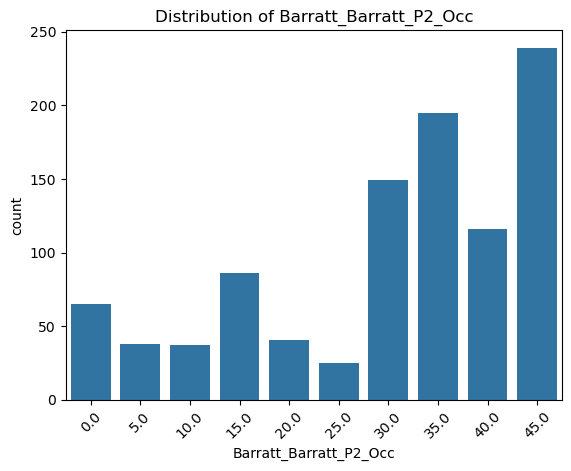

In [18]:
sns.countplot(x='Barratt_Barratt_P2_Occ', data=c_df[['Barratt_Barratt_P2_Occ']])
plt.title(f"Distribution of Barratt_Barratt_P2_Occ")
plt.xticks(rotation=45)
plt.show()

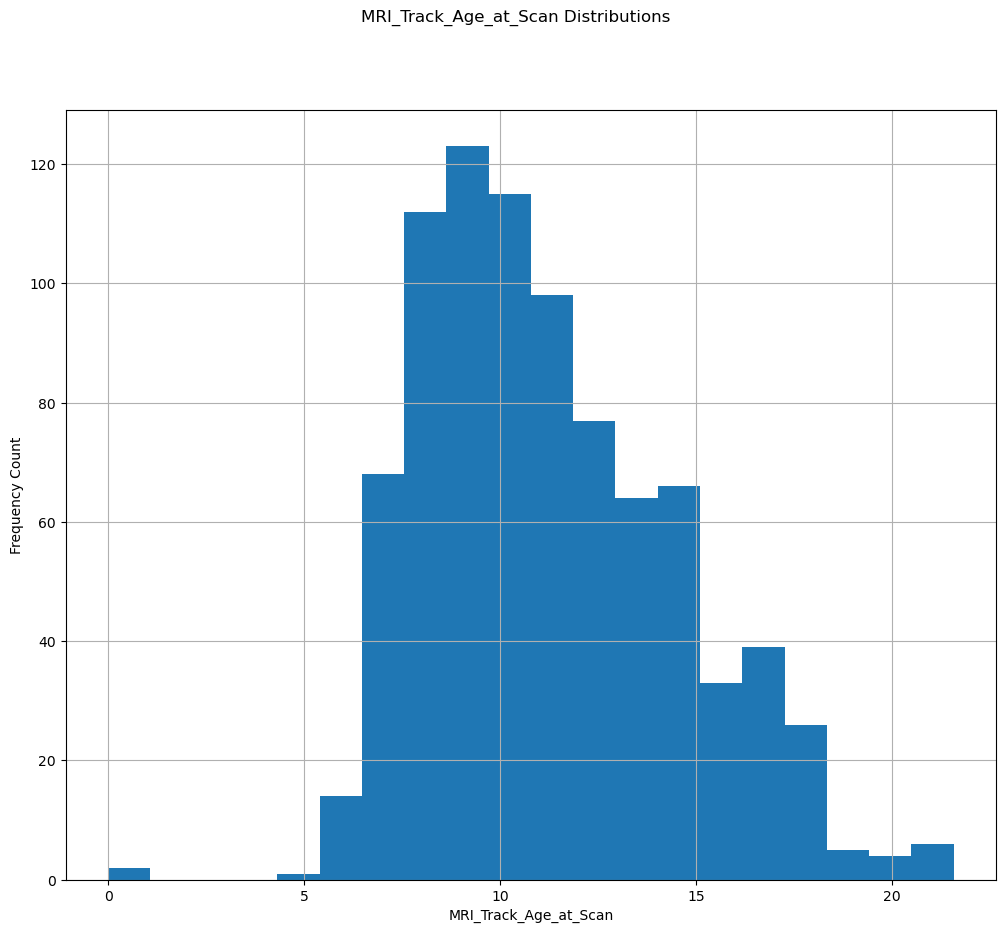

In [19]:
# Distribution of MRI_Track_Age_at_Scan
q_df['MRI_Track_Age_at_Scan'].hist(figsize=(12, 10), bins=20)
plt.suptitle("MRI_Track_Age_at_Scan Distributions")
plt.xlabel('MRI_Track_Age_at_Scan')
plt.ylabel('Frequency Count')
plt.show()


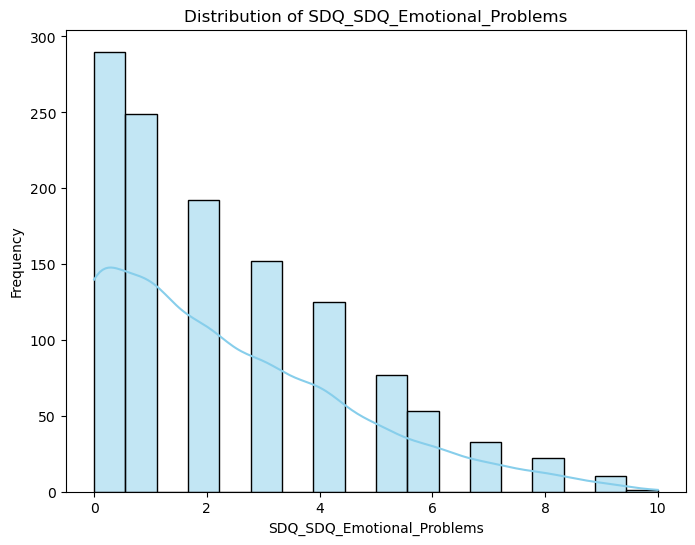

In [20]:
# Plot the distribution of the SDQ_SDQ_Emotional_Problems, which indicates Emotional Problems Scale.
plt.figure(figsize=(8, 6))
sns.histplot(q_df['SDQ_SDQ_Emotional_Problems'], kde=True, color='skyblue')
plt.title('Distribution of SDQ_SDQ_Emotional_Problems')
plt.xlabel('SDQ_SDQ_Emotional_Problems')
plt.ylabel('Frequency')
plt.show()

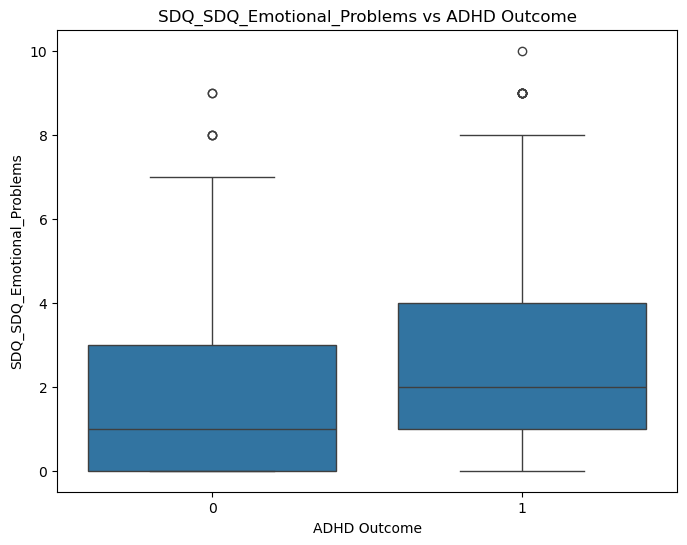

In [21]:
# Check for correlation with ADHD outcome
train_Quant_copy = q_df.copy()
train_Quant_copy['ADHD_Outcome'] = s_df['ADHD_Outcome']

plt.figure(figsize=(8, 6))
sns.boxplot(x='ADHD_Outcome', y='SDQ_SDQ_Emotional_Problems', data=train_Quant_copy)
plt.title('SDQ_SDQ_Emotional_Problems vs ADHD Outcome')
plt.xlabel('ADHD Outcome')
plt.ylabel('SDQ_SDQ_Emotional_Problems')
plt.show()


**Key insights:**
1. Higher Median for ADHD Group. This means people with ADHD tend to score higher on emotional problems.
2. More Variability (Spread) in ADHD Group. The height of the box + whiskers shows how spread out the data is. The box and whiskers for group 1 are taller/longer, meaning:
Emotional problem scores in the ADHD group are more spread out.

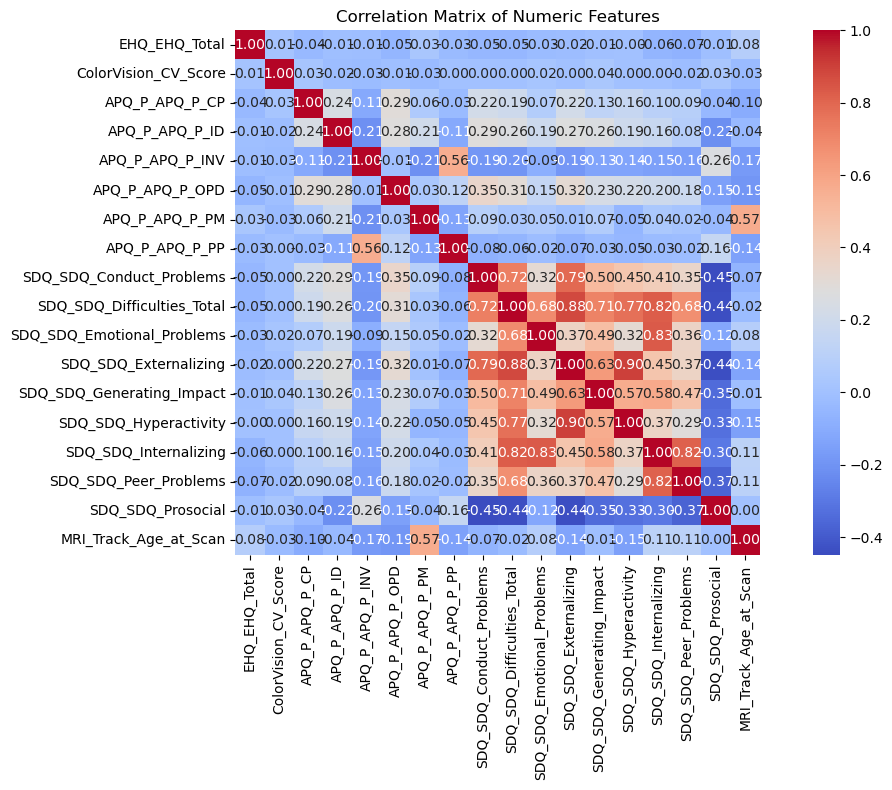

In [23]:
# Correlation matrix
correlation_matrix = q_df.select_dtypes(include='float64').corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

In [24]:
#Filter the upper triangle to avoid duplicate pairs and self-correlation
upper = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

#Find features with correlation > 0.7
high_corr_pairs = upper.stack().reset_index()
high_corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']
high_corr_pairs = high_corr_pairs[(high_corr_pairs['Correlation'] > 0.7) | (high_corr_pairs['Correlation'] < -0.7)]
print(high_corr_pairs)

                       Feature1                    Feature2  Correlation
108    SDQ_SDQ_Conduct_Problems  SDQ_SDQ_Difficulties_Total     0.723020
110    SDQ_SDQ_Conduct_Problems       SDQ_SDQ_Externalizing     0.794247
118  SDQ_SDQ_Difficulties_Total       SDQ_SDQ_Externalizing     0.876929
119  SDQ_SDQ_Difficulties_Total   SDQ_SDQ_Generating_Impact     0.712622
120  SDQ_SDQ_Difficulties_Total       SDQ_SDQ_Hyperactivity     0.769275
121  SDQ_SDQ_Difficulties_Total       SDQ_SDQ_Internalizing     0.824752
128  SDQ_SDQ_Emotional_Problems       SDQ_SDQ_Internalizing     0.831851
133       SDQ_SDQ_Externalizing       SDQ_SDQ_Hyperactivity     0.899033
147       SDQ_SDQ_Internalizing       SDQ_SDQ_Peer_Problems     0.817766


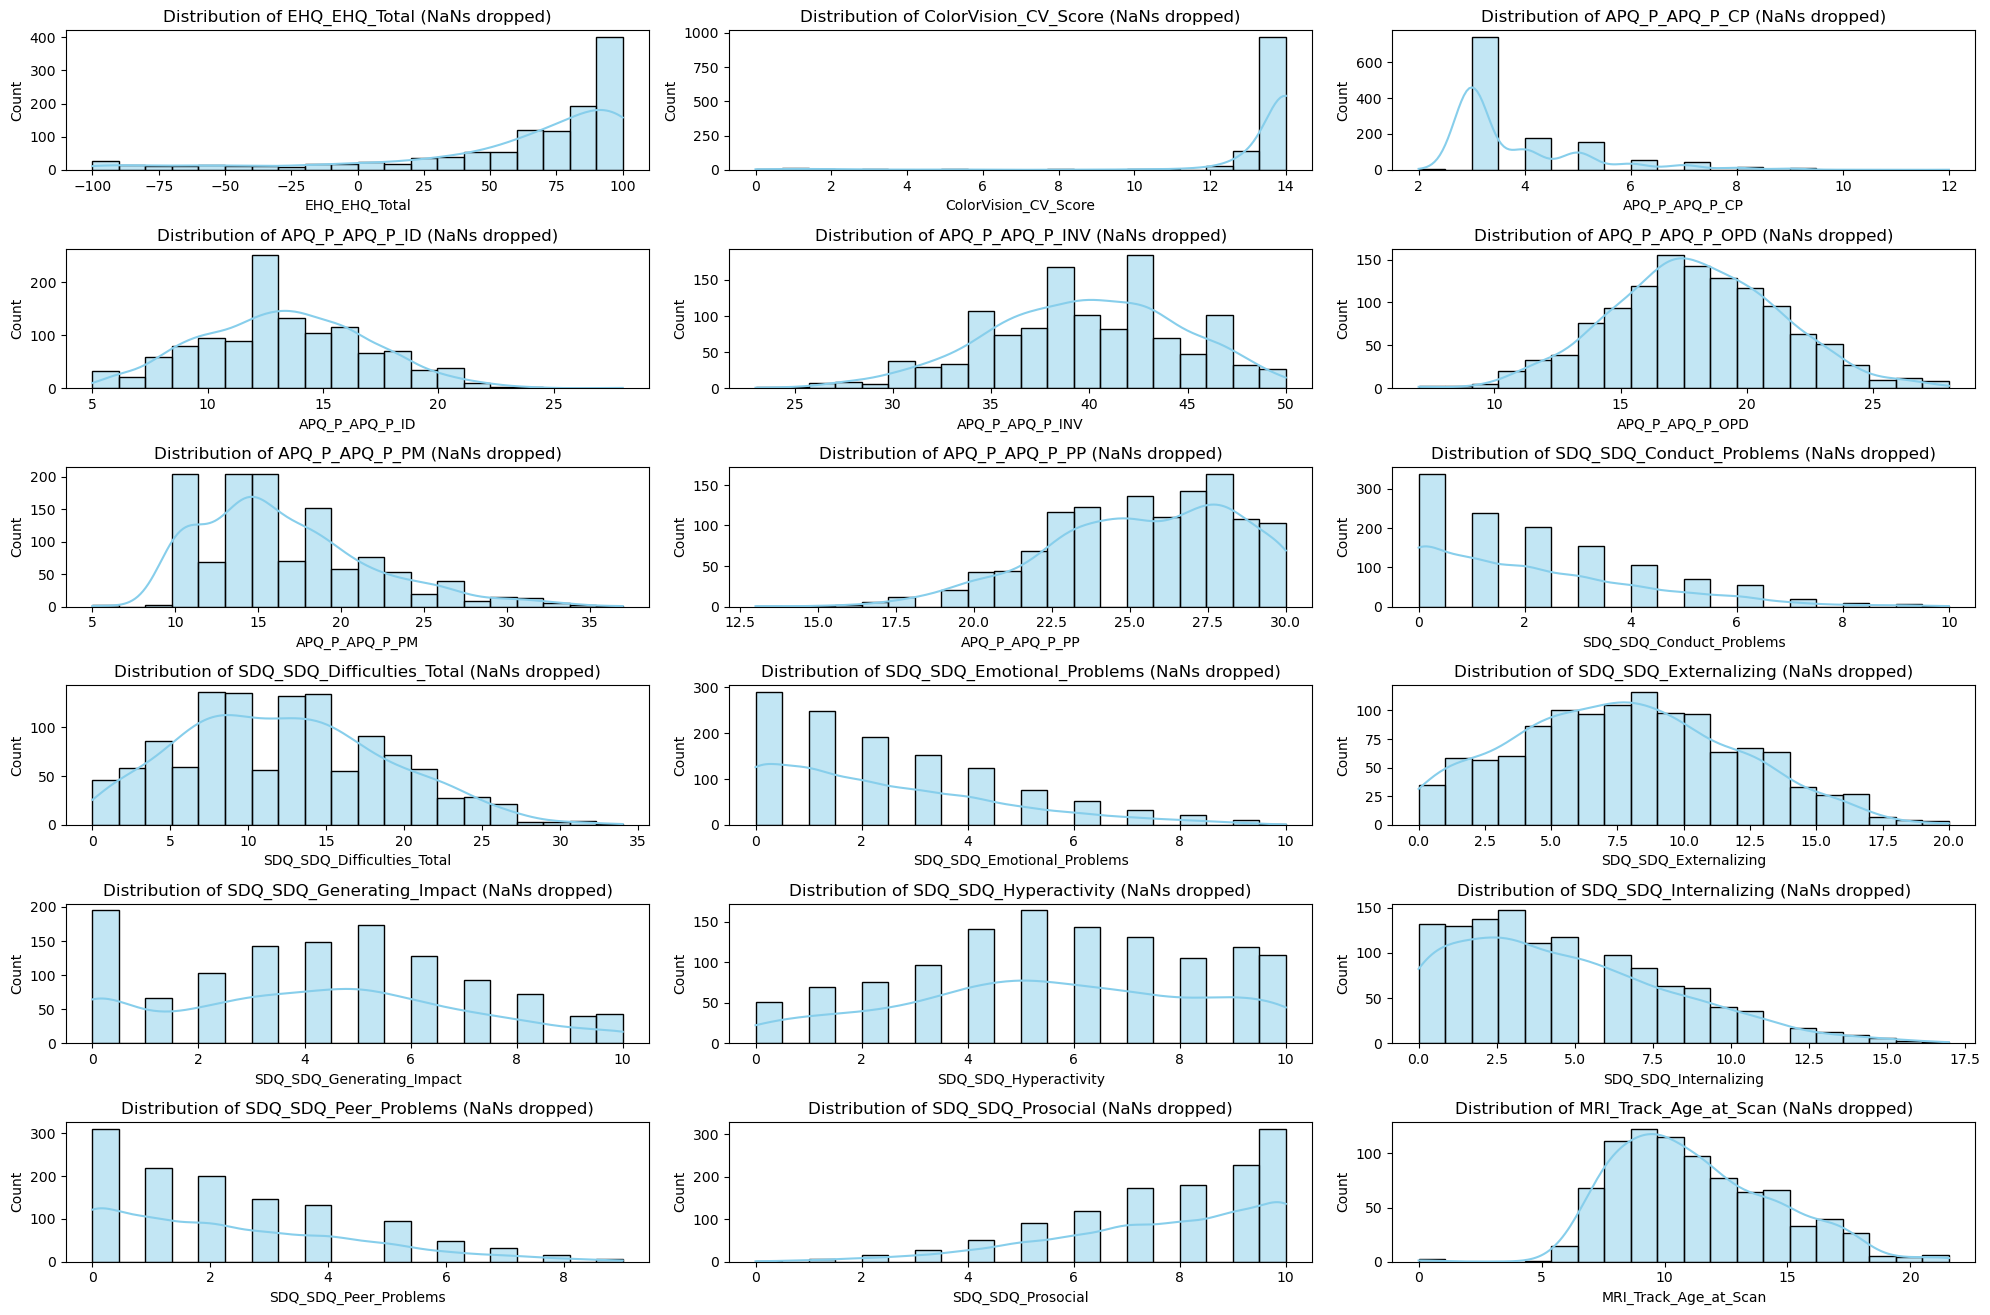

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

#Set up the matplotlib figure
plt.figure(figsize=(20, 15))

#Loop through each column and plot its distribution, dropping NaNs for each column
for i, column in enumerate(q_df.columns, 1):
    plt.subplot(len(q_df.columns) // 3 + 1, 3, i)
    sns.histplot(q_df[column].dropna(), kde=True, bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {column} (NaNs dropped)')
    plt.tight_layout()

plt.show()

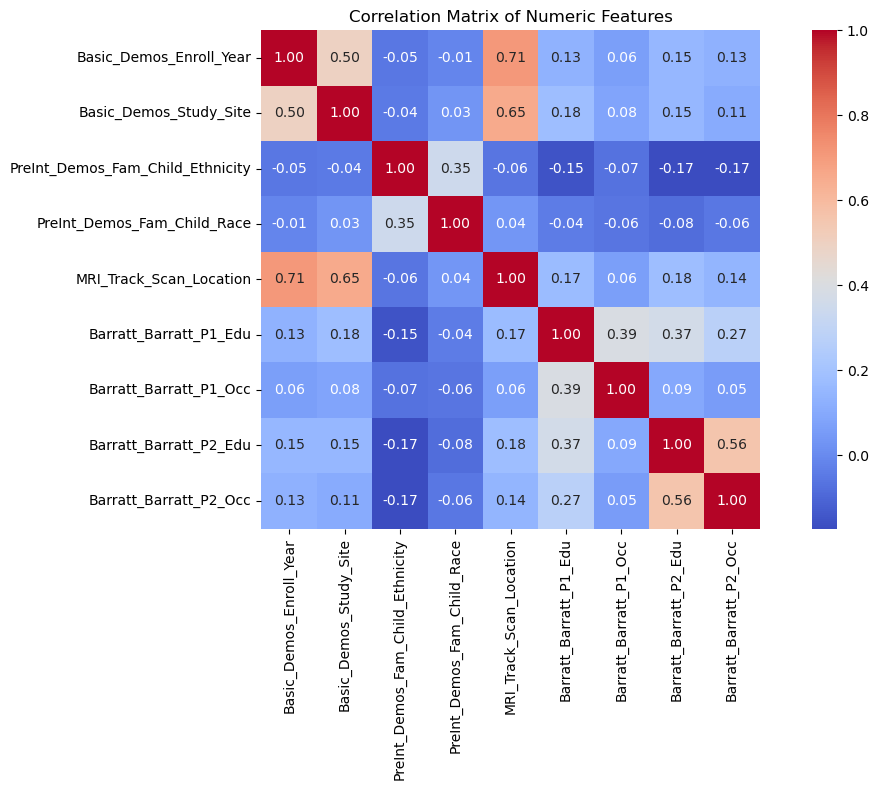

In [26]:
# Correlation matrix
correlation_matrix = c_df.select_dtypes(include=['float64', 'int64']).corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

In [27]:
#Filter the upper triangle to avoid duplicate pairs and self-correlation
upper = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

#Find features with correlation > 0.7
high_corr_pairs = upper.stack().reset_index()
high_corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']
high_corr_pairs = high_corr_pairs[(high_corr_pairs['Correlation'] > 0.7) | (high_corr_pairs['Correlation'] < -0.7)]
print(high_corr_pairs)

                  Feature1                 Feature2  Correlation
3  Basic_Demos_Enroll_Year  MRI_Track_Scan_Location     0.711119


Basic_Demos_Enroll_Year              6
Basic_Demos_Study_Site               4
PreInt_Demos_Fam_Child_Ethnicity     4
PreInt_Demos_Fam_Child_Race         10
MRI_Track_Scan_Location              4
Barratt_Barratt_P1_Edu               7
Barratt_Barratt_P1_Occ              10
Barratt_Barratt_P2_Edu               7
Barratt_Barratt_P2_Occ              10
dtype: int64
{'Basic_Demos_Enroll_Year': 0.4122011541632316, 'Basic_Demos_Study_Site': 0.9068425391591096, 'PreInt_Demos_Fam_Child_Ethnicity': 1.7094017094017095, 'PreInt_Demos_Fam_Child_Race': 0.1725625539257981, 'MRI_Track_Scan_Location': 2.975206611570248, 'Barratt_Barratt_P1_Edu': 0.41736227045075125, 'Barratt_Barratt_P1_Occ': 0.5076142131979695, 'Barratt_Barratt_P2_Edu': 0.49261083743842365, 'Barratt_Barratt_P2_Occ': 2.5227043390514634}


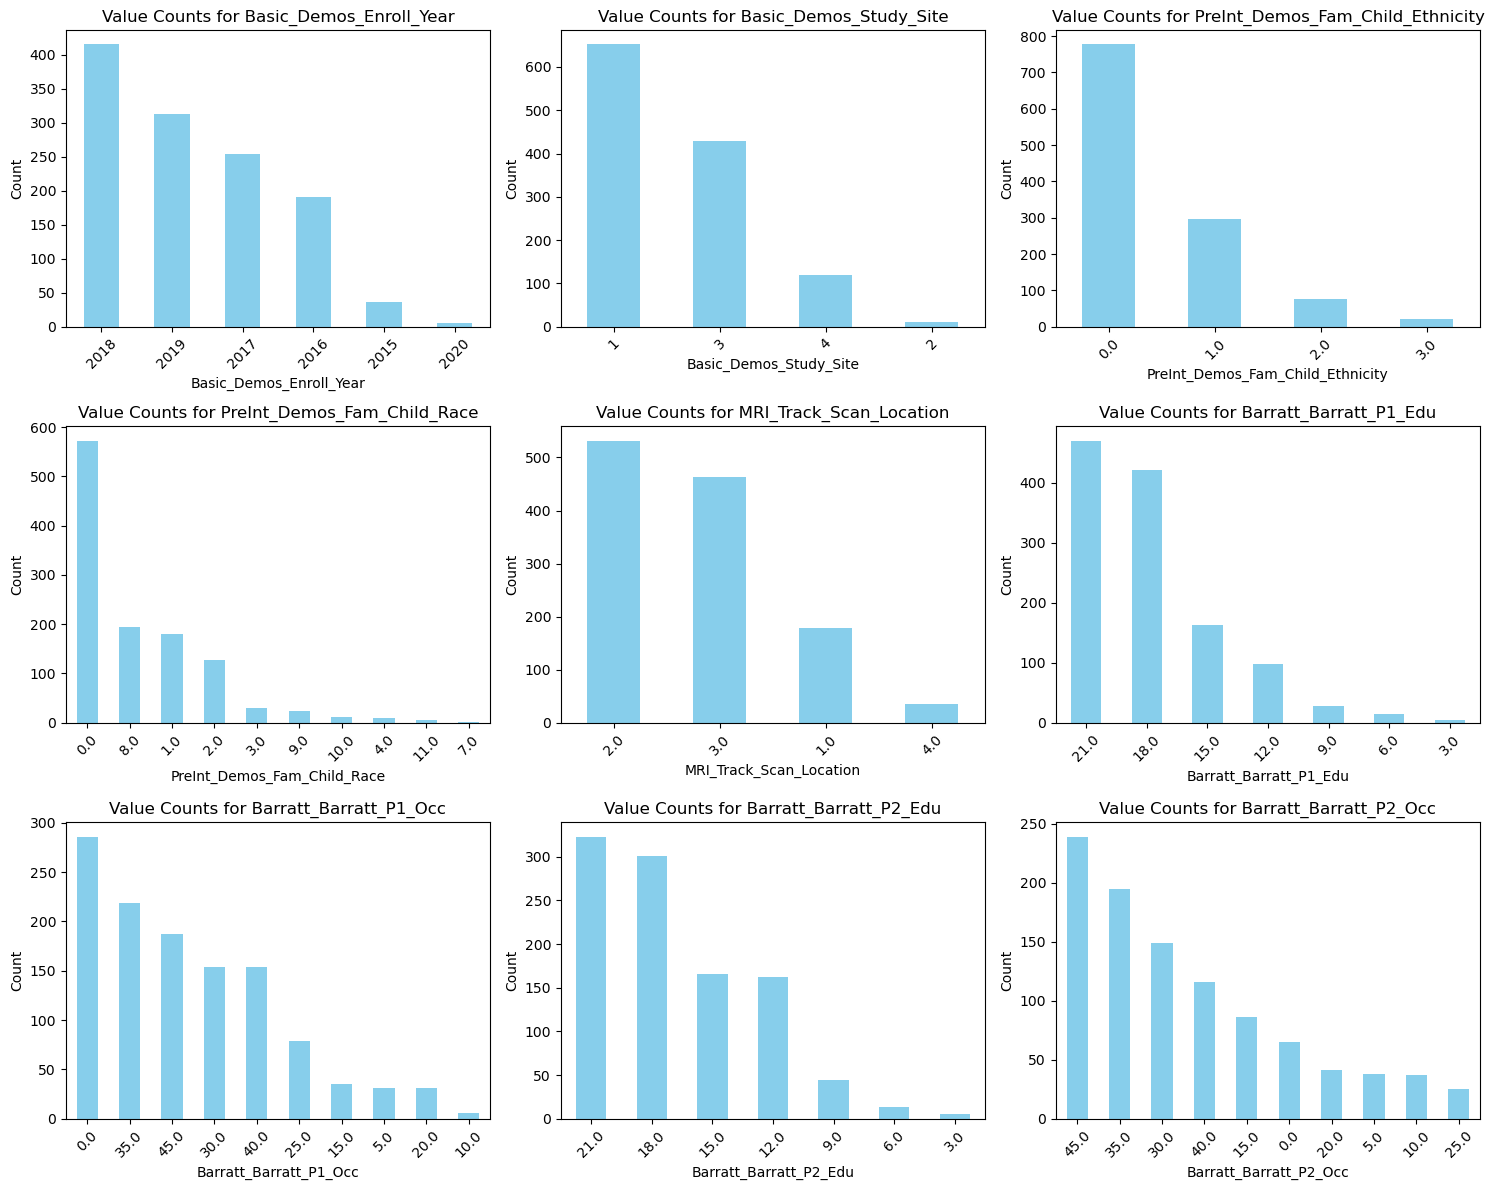

In [28]:
unique_counts = c_df.nunique()
print(unique_counts)
lowest_percentage = {}

for col in c_df.columns:
    # Get value counts and calculate the percentage
    value_counts = c_df[col].value_counts(normalize=True) * 100
    lowest_percentage[col] = value_counts.min()

print(lowest_percentage)
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

n_cols = 3  # Number of columns in the grid
n_rows = 3  # Number of rows in the grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(c_df.columns[:9]):  # Limit to first 9 columns
    c_df[col].value_counts().plot(kind='bar', color='skyblue', ax=axes[i])
    axes[i].set_title(f'Value Counts for {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for better readability

plt.tight_layout()
plt.show()


In [29]:
# ADHD distribution
s_df['ADHD_Outcome'].value_counts()

ADHD_Outcome
1    831
0    382
Name: count, dtype: int64

**Class imbalance**

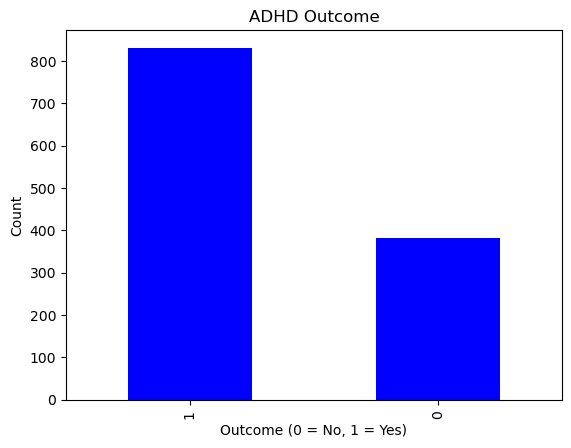

In [31]:
s_df['ADHD_Outcome'].value_counts().plot(kind='bar', color='blue')
plt.title('ADHD Outcome')
plt.xlabel('Outcome (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

In [32]:
# Gender distribution
s_df['Sex_F'].value_counts()

Sex_F
0    797
1    416
Name: count, dtype: int64

**Gender imbalance in the dataset may introduce bias in modeling.**

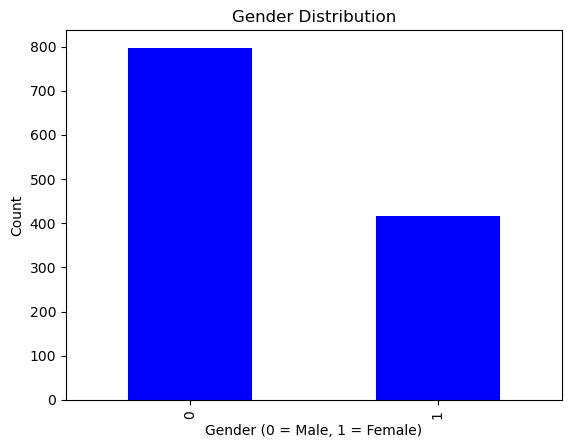

In [34]:
s_df['Sex_F'].value_counts().plot(kind='bar', color='blue')
plt.title('Gender Distribution')
plt.xlabel('Gender (0 = Male, 1 = Female)')
plt.ylabel('Count')
plt.show()

**3.Pre-processing**

**Missing Values**

In [37]:
miss_perc = q_df.isnull().mean() * 100
miss_perc

EHQ_EHQ_Total                  1.071723
ColorVision_CV_Score           1.896125
APQ_P_APQ_P_CP                 0.989283
APQ_P_APQ_P_ID                 0.989283
APQ_P_APQ_P_INV                0.989283
APQ_P_APQ_P_OPD                0.989283
APQ_P_APQ_P_PM                 0.989283
APQ_P_APQ_P_PP                 0.989283
SDQ_SDQ_Conduct_Problems       0.741962
SDQ_SDQ_Difficulties_Total     0.741962
SDQ_SDQ_Emotional_Problems     0.741962
SDQ_SDQ_Externalizing          0.741962
SDQ_SDQ_Generating_Impact      0.741962
SDQ_SDQ_Hyperactivity          0.741962
SDQ_SDQ_Internalizing          0.741962
SDQ_SDQ_Peer_Problems          0.741962
SDQ_SDQ_Prosocial              0.741962
MRI_Track_Age_at_Scan         29.678483
dtype: float64

     k       MAE      RMSE
0    1  3.374296  4.330085
1    2  2.773378  3.658142
2    3  2.425156  3.195768
3    4  2.306025  2.997167
4    5  2.263675  2.888698
5    6  2.192844  2.770120
6    7  2.179517  2.773919
7    8  2.170956  2.726890
8    9  2.145908  2.687449
9   10  2.135282  2.676334
10  11  2.147545  2.697451
11  12  2.128202  2.682239
12  13  2.138086  2.677573
13  14  2.147182  2.686263
14  15  2.171997  2.699075
15  16  2.169368  2.692835
16  17  2.161545  2.688964
17  18  2.153975  2.705287
18  19  2.153176  2.712091
19  20  2.166524  2.715611


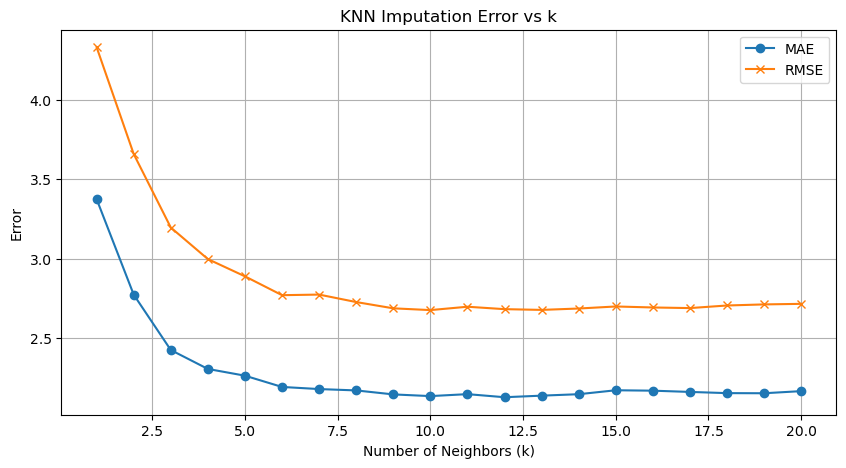

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Test different values of k
results = []
quantitative_df_copy = q_df.copy()
quantitative_df_old=q_df.copy()

for k in range(1, 21):  # Try k = 1 to 20
    # Copy the scaled data again for each loop
    test_data = quantitative_df_copy[quantitative_df_copy['MRI_Track_Age_at_Scan'].notnull()].copy()

    # Randomly mask 10% of values in 'MRI_Track_Age_at_Scan'
    np.random.seed(42)  # for reproducibility
    mask_indices = test_data.sample(frac=0.1).index
    true_values = test_data.loc[mask_indices, 'MRI_Track_Age_at_Scan'].copy()
    test_data.loc[mask_indices, 'MRI_Track_Age_at_Scan'] = np.nan

    # Apply KNN Imputer with current k
    knn_imputer = KNNImputer(n_neighbors=k)
    imputed_array = knn_imputer.fit_transform(test_data)

    # Extract imputed values
    row_positions = test_data.index.get_indexer(mask_indices)
    col_position = test_data.columns.get_loc('MRI_Track_Age_at_Scan')
    imputed_values = imputed_array[row_positions, col_position]

    # Calculate errors
    mae = mean_absolute_error(true_values, imputed_values)
    rmse = np.sqrt(mean_squared_error(true_values, imputed_values))

    results.append((k, mae, rmse))

# Convert results to DataFrame for easy analysis
results_df = pd.DataFrame(results, columns=['k', 'MAE', 'RMSE'])
print(results_df)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(results_df['k'], results_df['MAE'], marker='o', label='MAE')
plt.plot(results_df['k'], results_df['RMSE'], marker='x', label='RMSE')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Error')
plt.title('KNN Imputation Error vs k')
plt.legend()
plt.grid(True)
plt.show()

In [39]:
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

quantitative_df_copy = q_df.copy()
quantitative_df_old=q_df.copy()
#Step 2: Scale the data before applying KNN imputation
scaler = StandardScaler()

#Select columns for scaling, assuming you want to scale all columns except 'MRI_Track_Age_at_Scan'
columns_to_scale = quantitative_df_copy.drop(columns=['MRI_Track_Age_at_Scan']).columns

#Apply scaling
quantitative_df_copy[columns_to_scale] = scaler.fit_transform(quantitative_df_copy[columns_to_scale])

#Step 3: Initialize KNN Imputer
knn_imputer = KNNImputer(n_neighbors=9)

#Apply KNN imputation to 'MRI_Track_Age_at_Scan'
quantitative_df_copy['MRI_Track_Age_at_Scan'] = knn_imputer.fit_transform(quantitative_df_copy[['MRI_Track_Age_at_Scan']])
q_df['MRI_Track_Age_at_Scan'] =quantitative_df_copy['MRI_Track_Age_at_Scan'] 
#Step 4: After KNN, replace all remaining missing values in the entire dataframe with the median
q_df.fillna(quantitative_df_copy.median(), inplace=True)

#Step 5: Check the missing values after imputation
missing_values_after_imputation = q_df.isnull().sum()
print(f"Missing values after KNN and median imputation:\n{missing_values_after_imputation}")

Missing values after KNN and median imputation:
EHQ_EHQ_Total                 0
ColorVision_CV_Score          0
APQ_P_APQ_P_CP                0
APQ_P_APQ_P_ID                0
APQ_P_APQ_P_INV               0
APQ_P_APQ_P_OPD               0
APQ_P_APQ_P_PM                0
APQ_P_APQ_P_PP                0
SDQ_SDQ_Conduct_Problems      0
SDQ_SDQ_Difficulties_Total    0
SDQ_SDQ_Emotional_Problems    0
SDQ_SDQ_Externalizing         0
SDQ_SDQ_Generating_Impact     0
SDQ_SDQ_Hyperactivity         0
SDQ_SDQ_Internalizing         0
SDQ_SDQ_Peer_Problems         0
SDQ_SDQ_Prosocial             0
MRI_Track_Age_at_Scan         0
dtype: int64


In [40]:
miss_perc_c = c_df.isnull().mean() * 100
miss_perc_c

Basic_Demos_Enroll_Year              0.000000
Basic_Demos_Study_Site               0.000000
PreInt_Demos_Fam_Child_Ethnicity     3.544930
PreInt_Demos_Fam_Child_Race          4.451772
MRI_Track_Scan_Location              0.247321
Barratt_Barratt_P1_Edu               1.236603
Barratt_Barratt_P1_Occ               2.555647
Barratt_Barratt_P2_Edu              16.323166
Barratt_Barratt_P2_Occ              18.301731
dtype: float64

In [41]:
# Replace missing values in Barratt_Barratt_P2_Edu with -1
c_df['Barratt_Barratt_P2_Edu'] = c_df['Barratt_Barratt_P2_Edu'].fillna(-1)

# Replace missing values in Barratt_Barratt_P2_Occ with -1
c_df['Barratt_Barratt_P2_Occ'] = c_df['Barratt_Barratt_P2_Occ'].fillna(-1)

# Calculate the mode for each column and replace NaN values with the mode
c_df['PreInt_Demos_Fam_Child_Ethnicity'] = c_df['PreInt_Demos_Fam_Child_Ethnicity'].fillna(c_df['PreInt_Demos_Fam_Child_Ethnicity'].mode()[0])
c_df['PreInt_Demos_Fam_Child_Race'] = c_df['PreInt_Demos_Fam_Child_Race'].fillna(c_df['PreInt_Demos_Fam_Child_Race'].mode()[0])
c_df['MRI_Track_Scan_Location'] = c_df['MRI_Track_Scan_Location'].fillna(c_df['MRI_Track_Scan_Location'].mode()[0])
c_df['Barratt_Barratt_P1_Edu'] = c_df['Barratt_Barratt_P1_Edu'].fillna(c_df['Barratt_Barratt_P1_Edu'].mode()[0])
c_df['Barratt_Barratt_P1_Occ'] = c_df['Barratt_Barratt_P1_Occ'].fillna(c_df['Barratt_Barratt_P1_Occ'].mode()[0])
miss_perc_c = c_df.isnull().mean() * 100
miss_perc_c

Basic_Demos_Enroll_Year             0.0
Basic_Demos_Study_Site              0.0
PreInt_Demos_Fam_Child_Ethnicity    0.0
PreInt_Demos_Fam_Child_Race         0.0
MRI_Track_Scan_Location             0.0
Barratt_Barratt_P1_Edu              0.0
Barratt_Barratt_P1_Occ              0.0
Barratt_Barratt_P2_Edu              0.0
Barratt_Barratt_P2_Occ              0.0
dtype: float64

In [42]:
miss_perc_f = fnc_df.isnull().mean() * 100
miss_perc_f

0throw_1thcolumn        0.0
0throw_2thcolumn        0.0
0throw_3thcolumn        0.0
0throw_4thcolumn        0.0
0throw_5thcolumn        0.0
                       ... 
196throw_198thcolumn    0.0
196throw_199thcolumn    0.0
197throw_198thcolumn    0.0
197throw_199thcolumn    0.0
198throw_199thcolumn    0.0
Length: 19900, dtype: float64

**Outliers**

In [44]:
import pandas as pd

# Select only numerical columns
num_cols = q_df.select_dtypes(include='number').columns

# Initialize dictionaries to store counts and percentages
outlier_counts = {}
outlier_percentage = {}

# Iterate through numerical columns
for col in num_cols:
    Q1 = q_df[col].quantile(0.25)
    Q3 = q_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Detect outliers
    outliers = (q_df[col] < lower_bound) | (q_df[col] > upper_bound)
    
    # Count outliers for the current column
    outlier_counts[col] = outliers.sum()
    
    # Calculate the percentage of outliers for the current column
    outlier_percentage[col] = (outlier_counts[col] / len(q_df)) * 100

outlier_summary = pd.DataFrame({
    'Outlier Count': outlier_counts,
    'Outlier Percentage (%)': outlier_percentage
})

print("Outlier Summary (Count and Percentage):")
print(outlier_summary)

Outlier Summary (Count and Percentage):
                            Outlier Count  Outlier Percentage (%)
EHQ_EHQ_Total                         110                9.068425
ColorVision_CV_Score                  244               20.115416
APQ_P_APQ_P_CP                        139               11.459192
APQ_P_APQ_P_ID                         15                1.236603
APQ_P_APQ_P_INV                        15                1.236603
APQ_P_APQ_P_OPD                        25                2.061006
APQ_P_APQ_P_PM                         49                4.039571
APQ_P_APQ_P_PP                         14                1.154163
SDQ_SDQ_Conduct_Problems               17                1.401484
SDQ_SDQ_Difficulties_Total              1                0.082440
SDQ_SDQ_Emotional_Problems             11                0.906843
SDQ_SDQ_Externalizing                   2                0.164880
SDQ_SDQ_Generating_Impact               0                0.000000
SDQ_SDQ_Hyperactivity               

In [45]:
# Make a copy of the original DataFrame to apply capping/flooring
#q_df_capped = q_df.copy()

# Iterate through numerical columns again
for col in num_cols:
    Q1 = q_df[col].quantile(0.25)
    Q3 = q_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Apply capping and flooring
    q_df[col] = q_df[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers have been handled using capping and flooring.")


Outliers have been handled using capping and flooring.


In [46]:
import pandas as pd

# Select only numerical columns
num_cols = fnc_df.select_dtypes(include='number').columns

# Initialize dictionaries to store counts and percentages
outlier_counts = {}
outlier_percentage = {}

# Iterate through numerical columns
for col in num_cols:
    Q1 = fnc_df[col].quantile(0.25)
    Q3 = fnc_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Detect outliers
    outliers = (fnc_df[col] < lower_bound) | (fnc_df[col] > upper_bound)
    
    # Count outliers for the current column
    outlier_counts[col] = outliers.sum()
    
    # Calculate the percentage of outliers for the current column
    outlier_percentage[col] = (outlier_counts[col] / len(fnc_df)) * 100

outlier_summary = pd.DataFrame({
    'Outlier Count': outlier_counts,
    'Outlier Percentage (%)': outlier_percentage
})

print("Outlier Summary (Count and Percentage):")
print(outlier_summary)

Outlier Summary (Count and Percentage):
                      Outlier Count  Outlier Percentage (%)
0throw_1thcolumn                  4                0.329761
0throw_2thcolumn                 41                3.380049
0throw_3thcolumn                  8                0.659522
0throw_4thcolumn                 20                1.648805
0throw_5thcolumn                 37                3.050289
...                             ...                     ...
196throw_198thcolumn             19                1.566364
196throw_199thcolumn              8                0.659522
197throw_198thcolumn             11                0.906843
197throw_199thcolumn              6                0.494641
198throw_199thcolumn             19                1.566364

[19900 rows x 2 columns]


In [47]:
# Make a copy of the original DataFrame to apply capping/flooring
#fnc_df_capped = fnc_df.copy()

# Iterate through numerical columns again
for col in num_cols:
    Q1 = fnc_df[col].quantile(0.25)
    Q3 = fnc_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Apply capping and flooring
    fnc_df[col] = fnc_df[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers have been handled using capping and flooring.")


Outliers have been handled using capping and flooring.


**Normailzation**

In [49]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Apply Min-Max scaling
numeric_cols = q_df.select_dtypes(include=['float64', 'int64']).columns
q_df[numeric_cols] = scaler.fit_transform(q_df[numeric_cols])

q_df

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
participant_id,,,,,,,,,,,,,,,,,,
00aIpNTbG5uh,1.000000,0.0,0.375,0.575,0.755102,0.2500,0.666667,0.793103,0.402943,0.531729,0.479767,0.578947,0.501843,0.8,0.420622,0.233436,0.9,0.867242
00fV0OyyoLfw,0.938699,0.0,0.375,0.425,0.387755,0.9375,1.000000,1.000000,0.668302,0.625384,0.479767,0.684211,0.501843,0.8,0.488784,0.342945,0.8,0.549400
04X1eiS79T4B,0.894290,0.0,0.375,0.875,0.469388,0.5000,0.916667,0.862069,0.402943,0.750256,0.826589,0.526316,1.000000,0.7,0.965919,0.780982,0.7,0.782152
05ocQutkURd6,0.947185,0.0,0.375,0.375,0.673469,0.3125,0.666667,0.862069,0.004905,0.157113,0.017337,0.157895,0.003685,0.3,0.147973,0.233436,0.6,0.373803
06YUNBA9ZRLq,0.206979,0.0,1.000,0.425,0.387755,0.7500,0.333333,0.586207,0.800981,0.719038,0.826589,0.789474,0.800737,0.9,0.556946,0.123927,0.4,0.067556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zwjJWCRzKhDz,1.000000,0.0,0.375,0.525,0.428571,0.5000,0.375000,0.448276,0.668302,0.625384,0.595374,0.684211,0.501843,0.8,0.488784,0.233436,0.8,0.552266
zwXD5v17Rx01,0.577082,0.0,0.375,0.725,0.673469,0.6875,0.458333,0.655172,0.270263,0.157113,0.017337,0.263158,0.003685,0.3,0.011648,0.014417,0.7,0.142013
zWzLCi3NTBTd,0.000000,0.0,0.375,0.775,0.346939,0.6250,0.666667,0.655172,0.270263,0.438075,0.364159,0.473684,0.302580,0.7,0.352459,0.233436,0.9,0.414689


In [50]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Apply Min-Max scaling
numeric_cols = fnc_df.select_dtypes(include=['float64', 'int64']).columns
fnc_df[numeric_cols] = scaler.fit_transform(fnc_df[numeric_cols])

fnc_df

,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,0throw_10thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
participant_id,,,,,,,,,,,,,,,,,,,,,
70z8Q2xdTXM3,0.534505,0.483629,0.590272,0.181484,0.572646,0.224684,0.537373,0.166363,0.639840,0.685476,...,0.669666,0.946454,0.893412,0.659815,0.184317,0.550710,0.172075,0.602975,0.513686,0.326276
WHWymJu6zNZi,0.837733,0.550816,0.649901,0.618694,0.361500,0.394746,0.073252,0.159591,0.195668,0.511458,...,0.662653,0.563337,0.518594,0.400762,0.392504,0.473717,0.325934,0.654602,0.604115,0.498988
4PAQp1M6EyAo,0.271574,0.389023,0.437719,0.761466,0.837354,0.398580,0.692196,0.421974,0.634014,0.603274,...,0.780444,0.557207,0.484639,0.558833,0.334097,0.422133,0.553886,0.489874,0.556641,0.650543
obEacy4Of68I,0.516519,0.789677,0.796048,0.697375,0.737564,0.676491,0.554627,0.630186,0.645490,0.496407,...,0.555191,0.411052,0.705364,0.472448,0.367083,0.724607,0.375757,0.354278,0.478567,0.567866
s7WzzDcmDOhF,0.537903,0.599842,0.762848,0.684922,0.794776,0.599957,0.246581,0.580521,0.393176,0.560951,...,0.302037,0.583435,0.410951,0.039824,0.447117,0.000000,0.370132,0.032490,0.112942,0.004592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9gpepMI9sj5q,0.567282,0.516062,0.769041,0.770156,0.760910,0.000000,0.318193,0.575463,0.645848,0.568986,...,0.577379,0.697556,0.783432,0.595244,0.503771,0.247044,0.340180,0.173647,0.248713,0.591423
FIDen5rdMc0v,0.347767,0.550045,0.678132,0.449139,0.599240,0.577911,0.287322,0.525139,0.786957,0.653463,...,0.912177,0.428465,0.374054,0.403712,0.190417,0.272152,0.377930,0.408461,0.351583,0.167557
dlsMC4TXL4e8,0.537677,0.317212,0.223974,0.027568,0.000000,0.678931,0.843097,0.680232,0.281937,0.000000,...,0.099955,0.694941,0.690028,0.687317,0.358029,0.431636,0.262205,0.935009,0.322568,0.324295


In [51]:
# Merge all DataFrames on 'participant_id'
merged_df = q_df.merge(c_df, on='participant_id') \
                .merge(fnc_df, on='participant_id')
merged_df

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
participant_id,,,,,,,,,,,,,,,,,,,,,
00aIpNTbG5uh,1.000000,0.0,0.375,0.575,0.755102,0.2500,0.666667,0.793103,0.402943,0.531729,...,0.412794,0.487176,0.269542,0.524265,0.348527,0.371510,0.498051,0.423124,0.350643,0.543877
00fV0OyyoLfw,0.938699,0.0,0.375,0.425,0.387755,0.9375,1.000000,1.000000,0.668302,0.625384,...,0.322532,0.319781,0.222995,0.183025,0.535679,0.606344,0.592805,0.485844,0.333179,0.615171
04X1eiS79T4B,0.894290,0.0,0.375,0.875,0.469388,0.5000,0.916667,0.862069,0.402943,0.750256,...,0.331432,0.475890,0.516312,0.327831,0.706536,0.419699,0.651382,0.257249,0.631879,0.626694
05ocQutkURd6,0.947185,0.0,0.375,0.375,0.673469,0.3125,0.666667,0.862069,0.004905,0.157113,...,0.366438,0.538349,0.341162,0.290164,0.482756,0.428054,0.578813,0.546315,0.388529,0.428174
06YUNBA9ZRLq,0.206979,0.0,1.000,0.425,0.387755,0.7500,0.333333,0.586207,0.800981,0.719038,...,0.307658,0.322056,0.393113,0.487010,0.477298,0.465883,0.477891,0.468099,0.178971,0.342623
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zwjJWCRzKhDz,1.000000,0.0,0.375,0.525,0.428571,0.5000,0.375000,0.448276,0.668302,0.625384,...,0.606417,0.691224,0.618258,0.684394,0.597528,0.718699,0.474085,0.517376,0.192654,0.312645
zwXD5v17Rx01,0.577082,0.0,0.375,0.725,0.673469,0.6875,0.458333,0.655172,0.270263,0.157113,...,0.781121,0.761756,0.743515,0.672808,0.663316,0.182926,0.656788,0.103321,0.437614,0.541484
zWzLCi3NTBTd,0.000000,0.0,0.375,0.775,0.346939,0.6250,0.666667,0.655172,0.270263,0.438075,...,0.562047,0.574684,0.557814,0.706121,0.509873,0.151723,0.636751,0.077333,0.211119,0.097686


In [52]:
c_df.columns

Index(['Basic_Demos_Enroll_Year', 'Basic_Demos_Study_Site',
       'PreInt_Demos_Fam_Child_Ethnicity', 'PreInt_Demos_Fam_Child_Race',
       'MRI_Track_Scan_Location', 'Barratt_Barratt_P1_Edu',
       'Barratt_Barratt_P1_Occ', 'Barratt_Barratt_P2_Edu',
       'Barratt_Barratt_P2_Occ'],
      dtype='object')

In [53]:
columns_to_drop = [
    'Barratt_Barratt_P1_Occ',
    'Basic_Demos_Enroll_Year',
    'Basic_Demos_Study_Site',
    'MRI_Track_Scan_Location',
    'PreInt_Demos_Fam_Child_Race'
]
merged_df = merged_df.drop(columns=columns_to_drop)

**Machine Learning Models**

In [55]:
from sklearn.model_selection import train_test_split
# === DATA PREPARATION ===
X = merged_df
y = s_df

# Step 1: Merge X and y temporarily
full_data = X.copy()
full_data["ADHD_Outcome"] = y["ADHD_Outcome"]
full_data["Sex_F"] = y["Sex_F"]

# Step 2: Split full_data
train_data, test_data = train_test_split(
    full_data,
    test_size=0.3,
    random_state=42,
    stratify=full_data["Sex_F"]
)

# Step 3: Separate X and y again
X_train = train_data.drop(["ADHD_Outcome", "Sex_F"], axis=1)
y_train = train_data[["ADHD_Outcome", "Sex_F"]]

X_test = test_data.drop(["ADHD_Outcome", "Sex_F"], axis=1)
y_test = test_data[["ADHD_Outcome", "Sex_F"]]

X_train

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
participant_id,,,,,,,,,,,,,,,,,,,,,
SebKG45IfnXX,0.735686,0.0,0.375,0.225,0.510204,0.2500,0.583333,0.379310,0.270263,0.500511,...,0.680890,0.388217,0.416230,0.657522,0.417796,0.165782,0.833126,0.428267,0.668906,0.337056
9J8EUHnxePCd,0.259873,0.0,0.375,0.425,0.346939,0.6875,0.583333,1.000000,0.270263,0.500511,...,0.361033,0.411327,0.385009,0.484769,0.633802,0.590545,0.567116,0.465355,0.502046,0.362415
P5e504u4H6mf,0.947185,0.0,1.000,0.375,0.795918,0.3125,0.458333,0.862069,0.270263,0.438075,...,0.550662,0.363316,0.502937,0.391201,0.674420,0.725108,0.788266,0.693005,0.756045,0.666009
m4lTzGns4f6M,0.735686,0.0,0.375,0.575,0.632653,0.6875,0.458333,1.000000,0.004905,0.375639,...,0.512329,0.490464,0.473200,0.354593,0.599602,0.666447,0.800322,0.631298,0.850769,0.737350
l9I0XGZ2CKGk,0.894290,0.0,0.625,0.325,0.918367,0.5000,0.250000,0.793103,0.137584,0.313203,...,0.384112,0.414517,0.498194,0.561335,0.716938,0.592157,0.490701,0.669852,0.459485,0.699132
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
bq0EEKU9SiL7,0.788580,0.0,0.375,0.625,0.469388,0.3125,0.416667,0.310345,0.800981,0.843910,...,0.391752,0.425043,0.353930,0.513282,0.855520,0.790762,0.789316,0.771401,0.712166,0.623809
Gka80cgncOhF,0.771134,0.0,1.000,0.775,0.673469,0.7500,0.458333,0.931034,0.535622,0.500511,...,0.471751,0.452917,0.304806,0.456921,0.693833,0.631392,0.763132,0.772792,0.675773,0.452787
ffoXNugXGty5,0.629976,0.0,1.000,0.625,0.306122,0.7500,0.750000,0.310345,0.800981,0.750256,...,0.385865,0.601106,0.379154,0.304291,0.297446,0.301024,0.422596,0.237147,0.212244,0.547324


In [56]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Features and targets
# Keep only columns that are in both X_resampled and fnc_df
common_cols = X_train.columns.intersection(fnc_df.columns)
X = merged_df[common_cols]
y_sex = s_df['Sex_F']
y_adhd = s_df['ADHD_Outcome']

# Train logistic regression for Sex_F
model_sex = LogisticRegression(max_iter=10000)
model_sex.fit(X, y_sex)
coef_sex = pd.Series(model_sex.coef_[0], index=X.columns)
top_70_sex = coef_sex.abs().nlargest(30)

print("Top 30 Features for Predicting Sex_F:")
print(top_70_sex)

# Train logistic regression for ADHD_Outcome
model_adhd = LogisticRegression(max_iter=10000)
model_adhd.fit(X, y_adhd)
coef_adhd = pd.Series(model_adhd.coef_[0], index=X.columns)
top_70_adhd = coef_adhd.abs().nlargest(30)

print("\nTop 30 Features for Predicting ADHD_Outcome:")
print(top_70_adhd)
common_features = top_70_sex.index.intersection(top_70_adhd.index)
print(f"Features in both top 30s: {len(common_features)}")
print(list(common_features))

# Union of the top 70 features from both
union_features = top_70_sex.index.union(top_70_adhd.index)

print("\n Union of Top 30 Features:")
print(list(union_features))
print(f"\n Total Union Feature Count: {len(union_features)}")
# Step 1: Find common columns between X_resampled and fnc_df

# Step 2: Find the columns to drop (those in common but not in union_features)
cols_to_drop = [col for col in common_cols if col not in union_features]

# Step 3: Drop them from fnc_df
X_train = X_train.drop(columns=cols_to_drop)
merged_df = merged_df.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

🔝 Top 70 Features for Predicting Sex_F:
45throw_52thcolumn      0.278510
33throw_55thcolumn      0.265103
97throw_143thcolumn     0.229674
14throw_127thcolumn     0.223674
119throw_157thcolumn    0.220007
51throw_53thcolumn      0.219831
174throw_175thcolumn    0.213473
162throw_186thcolumn    0.213114
137throw_165thcolumn    0.211833
50throw_53thcolumn      0.211192
72throw_92thcolumn      0.210809
16throw_68thcolumn      0.205177
105throw_108thcolumn    0.204765
8throw_125thcolumn      0.204751
92throw_138thcolumn     0.203744
36throw_55thcolumn      0.203243
164throw_181thcolumn    0.200715
53throw_144thcolumn     0.200364
124throw_153thcolumn    0.200123
147throw_187thcolumn    0.199811
1throw_55thcolumn       0.198232
60throw_61thcolumn      0.198169
20throw_34thcolumn      0.195880
18throw_184thcolumn     0.195709
77throw_129thcolumn     0.195146
14throw_28thcolumn      0.193872
55throw_133thcolumn     0.193500
128throw_193thcolumn    0.192043
17throw_130thcolumn     0.190974
69t

In [57]:
X_train

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,...,128throw_193thcolumn,137throw_165thcolumn,143throw_150thcolumn,147throw_187thcolumn,149throw_161thcolumn,156throw_168thcolumn,157throw_172thcolumn,162throw_186thcolumn,164throw_181thcolumn,174throw_175thcolumn
participant_id,,,,,,,,,,,,,,,,,,,,,
SebKG45IfnXX,0.735686,0.0,0.375,0.225,0.510204,0.2500,0.583333,0.379310,0.270263,0.500511,...,0.552410,0.473768,0.327142,0.347468,0.574599,0.649311,0.700092,0.763355,0.772305,0.855046
9J8EUHnxePCd,0.259873,0.0,0.375,0.425,0.346939,0.6875,0.583333,1.000000,0.270263,0.500511,...,0.606474,0.452164,0.544205,0.281303,0.577043,0.428313,0.536537,0.672944,0.372077,0.486753
P5e504u4H6mf,0.947185,0.0,1.000,0.375,0.795918,0.3125,0.458333,0.862069,0.270263,0.438075,...,0.644534,0.494845,0.718380,0.199624,0.431353,0.413777,0.118704,0.467756,0.909783,0.671570
m4lTzGns4f6M,0.735686,0.0,0.375,0.575,0.632653,0.6875,0.458333,1.000000,0.004905,0.375639,...,0.303269,0.546278,0.467275,0.702323,0.456856,0.433473,0.312338,0.334307,0.705287,0.528136
l9I0XGZ2CKGk,0.894290,0.0,0.625,0.325,0.918367,0.5000,0.250000,0.793103,0.137584,0.313203,...,0.278971,0.724384,0.510514,0.783035,0.426990,0.535777,0.802985,0.184913,0.494810,0.363316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
bq0EEKU9SiL7,0.788580,0.0,0.375,0.625,0.469388,0.3125,0.416667,0.310345,0.800981,0.843910,...,0.545430,0.861853,0.777707,0.207049,0.538367,0.530600,0.514759,0.470233,0.834851,0.686454
Gka80cgncOhF,0.771134,0.0,1.000,0.775,0.673469,0.7500,0.458333,0.931034,0.535622,0.500511,...,0.817496,0.620873,0.625906,0.109803,0.629245,0.636267,0.409322,0.409775,0.711137,0.450565
ffoXNugXGty5,0.629976,0.0,1.000,0.625,0.306122,0.7500,0.750000,0.310345,0.800981,0.750256,...,0.389190,0.743763,0.243522,0.248367,0.388675,0.188563,0.348722,0.364090,0.665912,0.467187


In [58]:
X_test

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,...,128throw_193thcolumn,137throw_165thcolumn,143throw_150thcolumn,147throw_187thcolumn,149throw_161thcolumn,156throw_168thcolumn,157throw_172thcolumn,162throw_186thcolumn,164throw_181thcolumn,174throw_175thcolumn
participant_id,,,,,,,,,,,,,,,,,,,,,
tBP9frgzqhFI,0.000000,0.0,0.375,0.225,0.714286,0.3750,0.416667,0.724138,0.004905,0.063459,...,0.848351,0.730200,0.378588,0.588252,0.824596,0.445005,0.329038,0.706500,0.716026,0.000000
MMH1uM7wltAr,0.000000,0.0,0.375,0.475,0.591837,0.4375,0.458333,0.724138,0.000000,0.000000,...,0.678817,0.586972,0.602818,0.431653,0.352697,0.288387,0.170561,0.399878,0.248086,0.517915
e9KNj4GQUZXN,0.894290,0.0,0.875,0.275,0.469388,0.5625,0.250000,0.586207,0.137584,0.094677,...,0.194157,0.884884,0.597199,0.725156,0.588746,0.521290,0.401961,0.203405,0.425008,0.273854
VaBKvoEA40rs,1.000000,0.0,0.375,0.375,0.591837,0.3750,0.250000,0.517241,0.402943,0.406857,...,0.349711,0.852213,0.487918,0.350531,0.487389,0.595620,0.635197,0.223551,0.648519,0.000000
4JjEThZDJkAl,0.735686,0.0,0.625,0.375,0.591837,0.6250,0.500000,0.793103,0.137584,0.250767,...,0.382621,0.848730,0.389886,0.613560,0.528085,0.677143,0.512295,0.555870,0.652323,0.031741
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0ST9wPiJpQ8h,0.903251,0.0,0.875,0.575,0.428571,0.3750,0.791667,0.862069,0.004905,0.188331,...,0.453205,0.078055,0.789214,0.479196,0.384570,0.534741,0.755788,0.527440,0.684183,0.916146
evsCyrJNVy8i,1.000000,0.0,0.375,0.425,0.836735,0.3125,0.291667,0.655172,0.004905,0.219549,...,0.450708,0.640983,0.634092,0.237257,0.550715,0.271621,0.638024,0.496654,0.617505,0.392397
LviK6VKsIqzX,0.947185,0.0,0.375,0.425,0.428571,0.6250,0.708333,0.793103,0.535622,0.469293,...,0.804816,0.726820,0.214340,0.586301,0.616765,0.367136,0.178370,0.469205,0.708991,0.409557


In [59]:
merged_df

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,...,128throw_193thcolumn,137throw_165thcolumn,143throw_150thcolumn,147throw_187thcolumn,149throw_161thcolumn,156throw_168thcolumn,157throw_172thcolumn,162throw_186thcolumn,164throw_181thcolumn,174throw_175thcolumn
participant_id,,,,,,,,,,,,,,,,,,,,,
00aIpNTbG5uh,1.000000,0.0,0.375,0.575,0.755102,0.2500,0.666667,0.793103,0.402943,0.531729,...,0.686834,0.464091,0.588448,0.650633,0.662791,0.290407,0.988835,0.489576,0.486867,0.476378
00fV0OyyoLfw,0.938699,0.0,0.375,0.425,0.387755,0.9375,1.000000,1.000000,0.668302,0.625384,...,0.358040,0.456828,0.398702,0.310337,0.358913,0.551853,0.707813,0.401610,0.846988,0.829878
04X1eiS79T4B,0.894290,0.0,0.375,0.875,0.469388,0.5000,0.916667,0.862069,0.402943,0.750256,...,0.531925,0.582234,0.629156,0.505326,0.307129,0.737175,0.000000,0.331421,0.391129,0.716003
05ocQutkURd6,0.947185,0.0,0.375,0.375,0.673469,0.3125,0.666667,0.862069,0.004905,0.157113,...,0.393686,0.500983,0.714318,0.328350,0.727551,0.770164,0.411172,0.662553,0.218333,0.499712
06YUNBA9ZRLq,0.206979,0.0,1.000,0.425,0.387755,0.7500,0.333333,0.586207,0.800981,0.719038,...,0.596302,0.766592,0.306177,0.487398,0.342212,0.225531,0.545609,0.597115,0.679313,0.233221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zwjJWCRzKhDz,1.000000,0.0,0.375,0.525,0.428571,0.5000,0.375000,0.448276,0.668302,0.625384,...,0.621929,0.658968,0.658995,0.289596,0.558530,0.321952,0.474265,0.447528,0.706357,0.000000
zwXD5v17Rx01,0.577082,0.0,0.375,0.725,0.673469,0.6875,0.458333,0.655172,0.270263,0.157113,...,0.543782,0.729407,0.000000,0.672686,0.822333,0.363960,0.304724,0.602704,0.534718,0.767216
zWzLCi3NTBTd,0.000000,0.0,0.375,0.775,0.346939,0.6250,0.666667,0.655172,0.270263,0.438075,...,0.474660,0.250288,0.299947,0.351497,0.161169,0.731748,0.457788,0.548271,0.483249,0.421651


In [62]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import make_scorer, f1_score
import numpy as np

# === 2. CUSTOM METRIC ===
def custom_competition_metric(y_true, y_pred):
    # Ensure data is in int type for correct comparison
    adhd_true, sex_true = y_true[:, 0].astype(int), y_true[:, 1].astype(int)
    adhd_pred, sex_pred = y_pred[:, 0].astype(int), y_pred[:, 1].astype(int)

    # Initialize weights, giving double weight to Female ADHD cases (ADHD_Outcome=1, Sex_F=1)
    weights = np.ones_like(adhd_true, dtype=float)
    weights[(adhd_true == 1) & (sex_true == 1)] = 2.0  # Double weight for female ADHD

    # Calculate the true positives, false positives, and false negatives for ADHD
    tp_adhd = np.sum(((adhd_pred == 1) & (adhd_true == 1)) * weights)
    fp_adhd = np.sum(((adhd_pred == 1) & (adhd_true == 0)) * weights)
    fn_adhd = np.sum(((adhd_pred == 0) & (adhd_true == 1)) * weights)

    # Precision and Recall for ADHD
    precision_adhd = tp_adhd / (tp_adhd + fp_adhd + 1e-8)
    recall_adhd = tp_adhd / (tp_adhd + fn_adhd + 1e-8)
    f1_adhd = 2 * precision_adhd * recall_adhd / (precision_adhd + recall_adhd + 1e-8)

    # F1 score for Sex classification
    f1_sex = f1_score(sex_true, sex_pred, pos_label=1)

    # Return the average F1 score of both targets
    return (f1_adhd + f1_sex) / 2

custom_scorer = make_scorer(custom_competition_metric, greater_is_better=True)

In [61]:
X_train['Barratt_Barratt_P2_Edu'].unique()

array([ 9., -1., 21., 18., 15., 12.,  6.,  3.])

In [60]:
X_test['Barratt_Barratt_P2_Edu'].unique()

array([12., -1., 18., 21., 15.,  9.,  6.])

In [64]:
import pandas as pd
from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import OneHotEncoder

# Assuming 'selected_df' (features) and 'solutions_df' (targets) are already defined

# Example: Your data (use the actual data)
# X: feature data (already pre-processed with one-hot encoding for categorical features)
# y: target data (for example 'sex' and 'ADHD')
label_counts = y_train.value_counts()
print("Original label counts:\n", label_counts)
# Integer features (the ones you provided)
integer_features = [
    'ColorVision_CV_Score', 'APQ_P_APQ_P_CP', 'APQ_P_APQ_P_ID', 'APQ_P_APQ_P_INV',
    'APQ_P_APQ_P_OPD', 'APQ_P_APQ_P_PM', 'APQ_P_APQ_P_PP', 'SDQ_SDQ_Conduct_Problems',
    'SDQ_SDQ_Difficulties_Total', 'SDQ_SDQ_Emotional_Problems', 'SDQ_SDQ_Externalizing',
    'SDQ_SDQ_Generating_Impact', 'SDQ_SDQ_Hyperactivity', 'SDQ_SDQ_Internalizing',
    'SDQ_SDQ_Peer_Problems', 'SDQ_SDQ_Prosocial'
]

# Binary features (already one-hot encoded)
binary_features = [
   'PreInt_Demos_Fam_Child_Ethnicity','Barratt_Barratt_P1_Edu','Barratt_Barratt_P2_Edu','Barratt_Barratt_P2_Occ'
]

# Combine features and targets into one DataFrame
combined = pd.concat([X_train, y_train], axis=1)

# Separate features (X) and target (y)
X = combined.drop(columns=['ADHD_Outcome', 'Sex_F'])  # Features only (excluding target columns)
y = combined[['ADHD_Outcome', 'Sex_F']]  # Target columns

# Combine both target columns into a single column temporarily
y_combined = y.astype(str).agg('-'.join, axis=1)

# Identify categorical features (the binary ones)
categorical_features = [i for i, col in enumerate(X.columns) if col in binary_features]

# 1. Apply SMOTENC to handle imbalanced classes (on the combined target)
smote_nc = SMOTENC(categorical_features=categorical_features, random_state=42)
X_resampled, y_resampled_combined = smote_nc.fit_resample(X, y_combined)

# 2. Split the combined target back into 'sex' and 'ADHD' after resampling and name the columns
y_resampled = y_resampled_combined.str.split('-', expand=True).astype(int)

# Name the columns for clarity
y_resampled.columns = ['ADHD_Outcome', 'Sex_F']

# 3. For integer features, round the resampled data to ensure consistency
X_resampled[integer_features] = X_resampled[integer_features].round().astype(int)
# 4. One-hot encode the categorical features in the resampled X
#encoder = OneHotEncoder(drop='first', sparse=False)
X_resampled = pd.get_dummies(X_resampled, columns=binary_features, drop_first=False)
X_test = pd.get_dummies(X_test, columns=binary_features, drop_first=False)
X_test = X_test.reindex(columns=X_resampled.columns, fill_value=0)
merged_df = pd.get_dummies(merged_df, columns=binary_features, drop_first=False)
# Verify the result by checking the resampled features and targets

print("\nBalanced label counts:\n", pd.DataFrame(y_resampled).value_counts())

Original label counts:
 ADHD_Outcome  Sex_F
1             0        405
              1        176
0             0        153
              1        115
Name: count, dtype: int64

Balanced label counts:
 ADHD_Outcome  Sex_F
0             0        405
              1        405
1             0        405
              1        405
Name: count, dtype: int64


In [65]:
merged_df

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,...,Barratt_Barratt_P2_Occ_0.0,Barratt_Barratt_P2_Occ_5.0,Barratt_Barratt_P2_Occ_10.0,Barratt_Barratt_P2_Occ_15.0,Barratt_Barratt_P2_Occ_20.0,Barratt_Barratt_P2_Occ_25.0,Barratt_Barratt_P2_Occ_30.0,Barratt_Barratt_P2_Occ_35.0,Barratt_Barratt_P2_Occ_40.0,Barratt_Barratt_P2_Occ_45.0
participant_id,,,,,,,,,,,,,,,,,,,,,
00aIpNTbG5uh,1.000000,0.0,0.375,0.575,0.755102,0.2500,0.666667,0.793103,0.402943,0.531729,...,False,False,False,False,False,False,False,False,False,False
00fV0OyyoLfw,0.938699,0.0,0.375,0.425,0.387755,0.9375,1.000000,1.000000,0.668302,0.625384,...,False,False,False,False,False,False,False,False,False,True
04X1eiS79T4B,0.894290,0.0,0.375,0.875,0.469388,0.5000,0.916667,0.862069,0.402943,0.750256,...,False,False,False,False,False,False,False,False,False,False
05ocQutkURd6,0.947185,0.0,0.375,0.375,0.673469,0.3125,0.666667,0.862069,0.004905,0.157113,...,True,False,False,False,False,False,False,False,False,False
06YUNBA9ZRLq,0.206979,0.0,1.000,0.425,0.387755,0.7500,0.333333,0.586207,0.800981,0.719038,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zwjJWCRzKhDz,1.000000,0.0,0.375,0.525,0.428571,0.5000,0.375000,0.448276,0.668302,0.625384,...,False,True,False,False,False,False,False,False,False,False
zwXD5v17Rx01,0.577082,0.0,0.375,0.725,0.673469,0.6875,0.458333,0.655172,0.270263,0.157113,...,False,False,False,False,False,False,False,False,True,False
zWzLCi3NTBTd,0.000000,0.0,0.375,0.775,0.346939,0.6250,0.666667,0.655172,0.270263,0.438075,...,False,False,False,False,False,False,False,True,False,False


In [66]:
X_resampled

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,...,Barratt_Barratt_P2_Occ_0.0,Barratt_Barratt_P2_Occ_5.0,Barratt_Barratt_P2_Occ_10.0,Barratt_Barratt_P2_Occ_15.0,Barratt_Barratt_P2_Occ_20.0,Barratt_Barratt_P2_Occ_25.0,Barratt_Barratt_P2_Occ_30.0,Barratt_Barratt_P2_Occ_35.0,Barratt_Barratt_P2_Occ_40.0,Barratt_Barratt_P2_Occ_45.0
0,0.735686,0,0,0,1,0,1,0,0,1,...,False,False,False,False,False,True,False,False,False,False
1,0.259873,0,0,0,0,1,1,1,0,1,...,False,False,False,False,False,False,False,False,False,False
2,0.947185,0,1,0,1,0,0,1,0,0,...,False,False,False,False,False,False,False,True,False,False
3,0.735686,0,0,1,1,1,0,1,0,0,...,False,False,False,False,False,False,True,False,False,False
4,0.894290,0,1,0,1,0,0,1,0,0,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1615,0.716895,0,0,1,1,0,0,1,0,0,...,False,False,True,False,False,False,False,False,False,False
1616,0.239899,0,0,1,0,1,1,0,1,1,...,False,False,False,True,False,False,False,False,False,False
1617,0.842300,0,1,1,0,0,1,0,0,1,...,False,False,False,False,False,False,False,False,True,False
1618,0.963772,0,0,0,1,0,0,1,0,0,...,False,False,False,False,False,False,False,False,False,False


In [67]:
X_test

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,...,Barratt_Barratt_P2_Occ_0.0,Barratt_Barratt_P2_Occ_5.0,Barratt_Barratt_P2_Occ_10.0,Barratt_Barratt_P2_Occ_15.0,Barratt_Barratt_P2_Occ_20.0,Barratt_Barratt_P2_Occ_25.0,Barratt_Barratt_P2_Occ_30.0,Barratt_Barratt_P2_Occ_35.0,Barratt_Barratt_P2_Occ_40.0,Barratt_Barratt_P2_Occ_45.0
participant_id,,,,,,,,,,,,,,,,,,,,,
tBP9frgzqhFI,0.000000,0.0,0.375,0.225,0.714286,0.3750,0.416667,0.724138,0.004905,0.063459,...,False,False,False,False,False,False,True,False,False,False
MMH1uM7wltAr,0.000000,0.0,0.375,0.475,0.591837,0.4375,0.458333,0.724138,0.000000,0.000000,...,False,False,False,False,False,False,False,False,False,False
e9KNj4GQUZXN,0.894290,0.0,0.875,0.275,0.469388,0.5625,0.250000,0.586207,0.137584,0.094677,...,True,False,False,False,False,False,False,False,False,False
VaBKvoEA40rs,1.000000,0.0,0.375,0.375,0.591837,0.3750,0.250000,0.517241,0.402943,0.406857,...,False,False,False,False,False,False,False,False,False,True
4JjEThZDJkAl,0.735686,0.0,0.625,0.375,0.591837,0.6250,0.500000,0.793103,0.137584,0.250767,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0ST9wPiJpQ8h,0.903251,0.0,0.875,0.575,0.428571,0.3750,0.791667,0.862069,0.004905,0.188331,...,False,False,False,True,False,False,False,False,False,False
evsCyrJNVy8i,1.000000,0.0,0.375,0.425,0.836735,0.3125,0.291667,0.655172,0.004905,0.219549,...,False,False,False,False,False,False,False,False,False,True
LviK6VKsIqzX,0.947185,0.0,0.375,0.425,0.428571,0.6250,0.708333,0.793103,0.535622,0.469293,...,False,False,False,False,False,False,False,False,True,False


In [68]:
# Get sets of column names
merg_columns = set(merged_df.columns)
selected_columns = set(X_resampled.columns)

# Find differences
only_in_merg = merg_columns - selected_columns
only_in_selected = selected_columns - merg_columns

# Report differences
if only_in_merg:
    print("Columns only in merged_df:")
    for col in sorted(only_in_merg):
        print(f"  - {col}")
else:
    print("No columns are unique to merged_df.")

if only_in_selected:
    print("\nColumns only in X_resampled:")
    for col in sorted(only_in_selected):
        print(f"  - {col}")
else:
    print("\nNo columns are unique to X_resampled.")


No columns are unique to merged_df.

No columns are unique to X_resampled.


In [69]:
# Get sets of column names
merg_columns = set(X_resampled.columns)
selected_columns = set(X_test.columns)

# Find differences
only_in_merg = merg_columns - selected_columns
only_in_selected = selected_columns - merg_columns

# Report differences
if only_in_merg:
    print("Columns only in X_train:")
    for col in sorted(only_in_merg):
        print(f"  - {col}")
else:
    print("No columns are unique to X_train.")

if only_in_selected:
    print("\nColumns only in X_test:")
    for col in sorted(only_in_selected):
        print(f"  - {col}")
else:
    print("\nNo columns are unique to X_test.")


No columns are unique to X_train.

No columns are unique to X_test.


**1.KNN**

Best Params: {'clf__estimator__algorithm': 'auto', 'clf__estimator__leaf_size': 20, 'clf__estimator__n_neighbors': 2, 'clf__estimator__p': 1, 'clf__estimator__weights': 'distance'}
Best Custom Score (Train): 0.7151724397342012
Custom Score (Test): 0.5655667120953144
F1 Score for ADHD: 0.6488
Accuracy for ADHD: 0.6044
F1 Score for Sex (F): 0.4824
Accuracy for Sex (F): 0.5165
Joint Accuracy: 0.3077

 Classification Report for ADHD:
              precision    recall  f1-score   support

           0       0.43      0.76      0.55       114
           1       0.83      0.53      0.65       250

    accuracy                           0.60       364
   macro avg       0.63      0.65      0.60       364
weighted avg       0.70      0.60      0.62       364



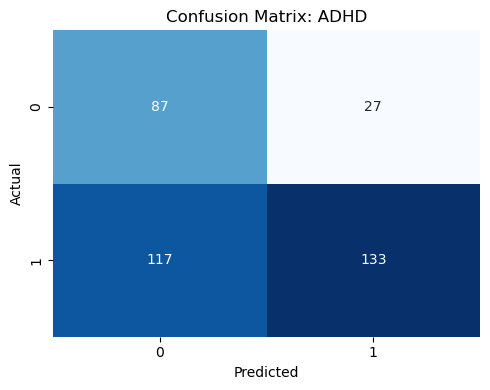


 Classification Report for Sex (F):
              precision    recall  f1-score   support

           0       0.71      0.44      0.55       239
           1       0.38      0.66      0.48       125

    accuracy                           0.52       364
   macro avg       0.55      0.55      0.51       364
weighted avg       0.60      0.52      0.52       364



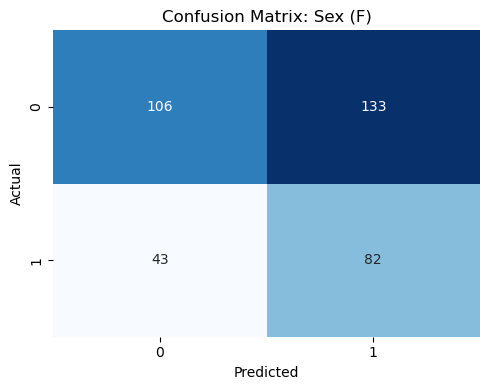

In [127]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.multioutput import MultiOutputClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# === PIPELINE + KNN ===
knn = KNeighborsClassifier()
multi_knn = MultiOutputClassifier(knn)

pipeline = Pipeline([
    ("clf", multi_knn)         
])

# === GRID SEARCH ===
param_grid = {
    "clf__estimator__n_neighbors": [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
    "clf__estimator__weights": ['uniform', 'distance'],
    "clf__estimator__algorithm": ['auto', 'ball_tree', 'kd_tree', 'brute'],
    "clf__estimator__leaf_size": [20, 30, 40],
    "clf__estimator__p": [1, 2],
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=custom_scorer,  
    refit=True,
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_resampled, y_resampled.values)

# === BEST MODEL ===
print("Best Params:", grid_search.best_params_)
print("Best Custom Score (Train):", grid_search.best_score_)

best_model_KNN = grid_search.best_estimator_
y_pred = best_model_KNN.predict(X_test)
y_test_np = y_test.values

# === EVALUATION ON TEST SET ===
test_score = custom_competition_metric(y_test_np, y_pred)
print("Custom Score (Test):", test_score)

# === F1 SCORES AND ACCURACY ===
for i, label in enumerate(["ADHD", "Sex (F)"]):
    f1 = f1_score(y_test_np[:, i], y_pred[:, i])
    print(f"F1 Score for {label}: {f1:.4f}")

    accuracy = np.mean(y_test_np[:, i] == y_pred[:, i])
    print(f"Accuracy for {label}: {accuracy:.4f}")

# === JOINT ACCURACY ===
joint_accuracy = np.mean(np.all(y_test_np == y_pred, axis=1))
print(f"Joint Accuracy: {joint_accuracy:.4f}")

# === REPORTS & CONFUSION MATRICES ===
for i, label in enumerate(["ADHD", "Sex (F)"]):
    print(f"\n Classification Report for {label}:")
    print(classification_report(y_test_np[:, i], y_pred[:, i]))

    cm = confusion_matrix(y_test_np[:, i], y_pred[:, i])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix: {label}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0.5, 1.5], ["0", "1"])
    plt.yticks([0.5, 1.5], ["0", "1"])
    plt.tight_layout()
    plt.show()

In [129]:
import joblib

# Assuming your model is in the variable model
joblib.dump(best_model_KNN, 'KNN_model_SMOTE_test.pkl')

['KNN_model_SMOTE_test.pkl']

**Using the trained model on the original dataset before oversampling**

Evaluation on Original Unbalanced Data:
F1 Score for ADHD: 0.9084
Accuracy for ADHD: 0.8813
F1 Score for Sex (F): 0.8091
Accuracy for Sex (F): 0.8549
Joint Accuracy: 0.7923


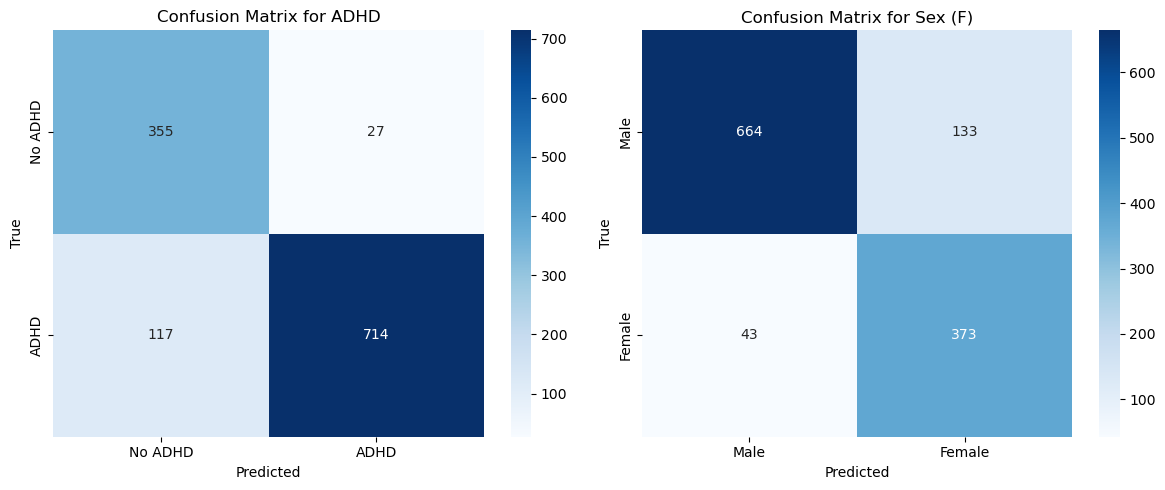

In [131]:
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score

# Assuming best_model is the trained model from your resampled data
# Combine features and targets and drop any rows with NaNs
original_combined = pd.concat([merged_df, s_df], axis=1).dropna()
X_orig = original_combined[merged_df.columns]
y_orig = original_combined[s_df.columns]

# Predict on the original unbalanced data
y_pred = best_model_KNN.predict(X_orig)

# Convert predictions to DataFrame (if they are numpy arrays)
y_pred_df = pd.DataFrame(y_pred, columns=y_orig.columns)

# Align y_pred_df with y_orig's original index
y_pred_df.index = y_orig.index

# Evaluate ADHD metrics
adhd_f1 = f1_score(y_orig['ADHD_Outcome'], y_pred_df['ADHD_Outcome'])
adhd_acc = accuracy_score(y_orig['ADHD_Outcome'], y_pred_df['ADHD_Outcome'])

# Evaluate Sex (F) metrics
sex_f1 = f1_score(y_orig['Sex_F'], y_pred_df['Sex_F'])
sex_acc = accuracy_score(y_orig['Sex_F'], y_pred_df['Sex_F'])

# Joint Accuracy (both labels correct)
joint_acc = ((y_orig == y_pred_df).all(axis=1)).mean()

# Print the evaluation metrics
print(f"Evaluation on Original Unbalanced Data:")
print(f"F1 Score for ADHD: {adhd_f1:.4f}")
print(f"Accuracy for ADHD: {adhd_acc:.4f}")
print(f"F1 Score for Sex (F): {sex_f1:.4f}")
print(f"Accuracy for Sex (F): {sex_acc:.4f}")
print(f"Joint Accuracy: {joint_acc:.4f}")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix for ADHD (ADHD_Outcome)
adhd_cm = confusion_matrix(y_orig['ADHD_Outcome'], y_pred_df['ADHD_Outcome'])

# Generate confusion matrix for Sex (F)
sex_cm = confusion_matrix(y_orig['Sex_F'], y_pred_df['Sex_F'])

# Plot ADHD confusion matrix
plt.figure(figsize=(12, 5))

# ADHD confusion matrix plot
plt.subplot(1, 2, 1)
sns.heatmap(adhd_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No ADHD", "ADHD"], yticklabels=["No ADHD", "ADHD"])
plt.title("Confusion Matrix for ADHD")
plt.xlabel("Predicted")
plt.ylabel("True")

# Sex confusion matrix plot
plt.subplot(1, 2, 2)
sns.heatmap(sex_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Male", "Female"], yticklabels=["Male", "Female"])
plt.title("Confusion Matrix for Sex (F)")
plt.xlabel("Predicted")
plt.ylabel("True")

# Show the plot
plt.tight_layout()
plt.show()


**2.Decision Tree**

Best Params: {'clf__estimator__criterion': 'gini', 'clf__estimator__max_depth': 22, 'clf__estimator__max_features': None, 'clf__estimator__min_samples_leaf': 1, 'clf__estimator__min_samples_split': 2, 'clf__estimator__splitter': 'best'}
Best Custom Score (Train): 0.6342204732354204
Custom Score (Test): 0.5925920521011547
F1 Score for ADHD: 0.7510
Accuracy for ADHD: 0.6648
F1 Score for Sex (F): 0.4342
Accuracy for Sex (F): 0.5632
Joint Accuracy: 0.3984

 Classification Report for ADHD:
              precision    recall  f1-score   support

           0       0.47      0.51      0.49       114
           1       0.77      0.74      0.75       250

    accuracy                           0.66       364
   macro avg       0.62      0.62      0.62       364
weighted avg       0.67      0.66      0.67       364



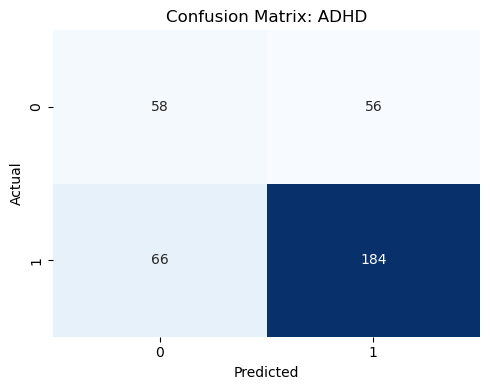


 Classification Report for Sex (F):
              precision    recall  f1-score   support

           0       0.69      0.60      0.64       239
           1       0.39      0.49      0.43       125

    accuracy                           0.56       364
   macro avg       0.54      0.55      0.54       364
weighted avg       0.59      0.56      0.57       364



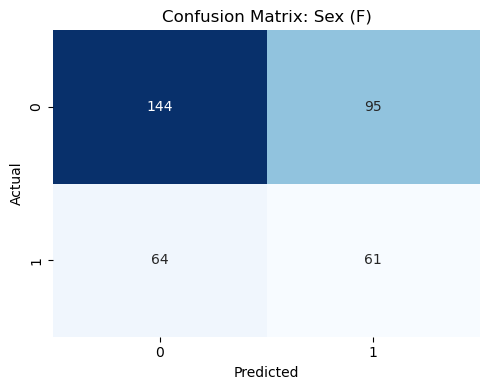

In [133]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputClassifier

# === PIPELINE + DECISION TREE ===
dt = DecisionTreeClassifier(random_state=42)

multi_dt = MultiOutputClassifier(dt)

pipeline = Pipeline([
    ("clf", multi_dt)
])

# === GRID SEARCH ===
param_grid = {
    "clf__estimator__max_depth": [13,14,15,15,17,18,19,20,21,22],  # Max depth of the tree
    "clf__estimator__min_samples_split": [2, 3,4,5,6,7,8],  # Minimum samples required to split a node
    "clf__estimator__min_samples_leaf": [1, 2,3,4],  # Minimum samples required to be at a leaf node
    "clf__estimator__criterion": ['gini'],  # Criterion for splitting nodes
    "clf__estimator__max_features": [None],  # Number of features to consider for the best split
    "clf__estimator__splitter": ['best', 'random']  # Strategy for splitting nodes
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=custom_scorer,
    refit=True,
    cv=5,
   
    n_jobs=-1
)

grid_search.fit(X_resampled, y_resampled.values)

# === BEST MODEL ===
print("Best Params:", grid_search.best_params_)
print("Best Custom Score (Train):", grid_search.best_score_)

best_model_DT = grid_search.best_estimator_
y_pred = best_model_DT.predict(X_test)
y_test_np = y_test.values

# === EVALUATION ON TEST SET ===
test_score = custom_competition_metric(y_test_np, y_pred)
print("Custom Score (Test):", test_score)

# === F1 SCORES AND ACCURACY ===
for i, label in enumerate(["ADHD", "Sex (F)"]):
    # F1 score
    f1 = f1_score(y_test_np[:, i], y_pred[:, i])
    print(f"F1 Score for {label}: {f1:.4f}")

    # Accuracy
    accuracy = np.mean(y_test_np[:, i] == y_pred[:, i])
    print(f"Accuracy for {label}: {accuracy:.4f}")

# === JOINT ACCURACY ===
joint_accuracy = np.mean(np.all(y_test_np == y_pred, axis=1))
print(f"Joint Accuracy: {joint_accuracy:.4f}")

# === REPORTS & CONFUSION MATRICES ===
for i, label in enumerate(["ADHD", "Sex (F)"]):
    print(f"\n Classification Report for {label}:")
    print(classification_report(y_test_np[:, i], y_pred[:, i]))

    cm = confusion_matrix(y_test_np[:, i], y_pred[:, i])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix: {label}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0.5, 1.5], ["0", "1"])
    plt.yticks([0.5, 1.5], ["0", "1"])
    plt.tight_layout()
    plt.show()


In [134]:
import joblib

# Assuming your model is in the variable model
joblib.dump(best_model_DT, 'DT_model_SMOTE_test.pkl')

['DT_model_SMOTE_test.pkl']

**Using the trained model on the original dataset before oversampling**

Evaluation on Original Unbalanced Data:
F1 Score for ADHD: 0.9229
Accuracy for ADHD: 0.8953
F1 Score for Sex (F): 0.8158
Accuracy for Sex (F): 0.8689
Joint Accuracy: 0.8153


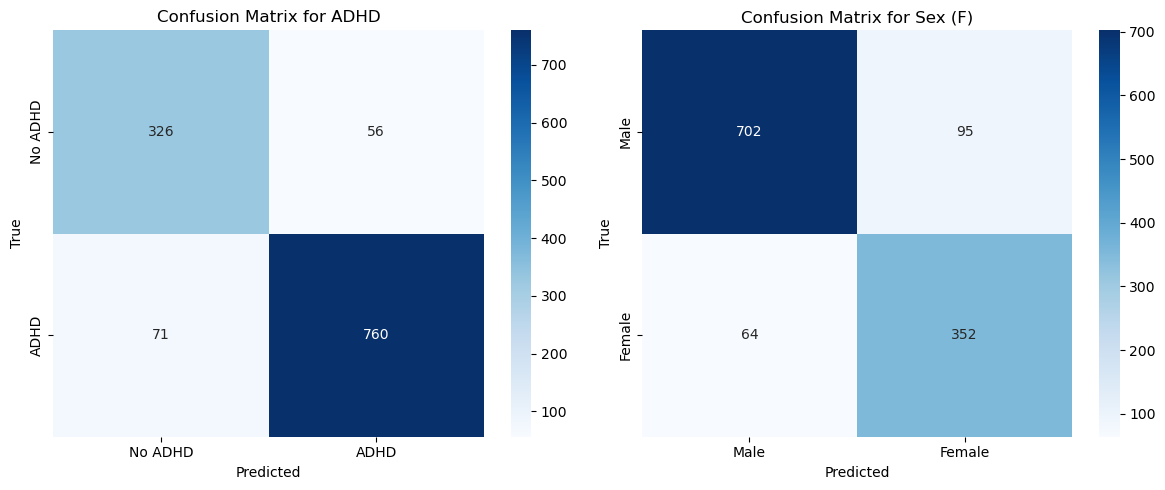

In [136]:
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score

# Assuming best_model is the trained model from your resampled data
# Combine features and targets and drop any rows with NaNs
original_combined = pd.concat([merged_df, s_df], axis=1).dropna()
X_orig = original_combined[merged_df.columns]
y_orig = original_combined[s_df.columns]

# Predict on the original unbalanced data
y_pred = best_model_DT.predict(X_orig)

# Convert predictions to DataFrame (if they are numpy arrays)
y_pred_df = pd.DataFrame(y_pred, columns=y_orig.columns)

# Align y_pred_df with y_orig's original index
y_pred_df.index = y_orig.index

# Evaluate ADHD metrics
adhd_f1 = f1_score(y_orig['ADHD_Outcome'], y_pred_df['ADHD_Outcome'])
adhd_acc = accuracy_score(y_orig['ADHD_Outcome'], y_pred_df['ADHD_Outcome'])

# Evaluate Sex (F) metrics
sex_f1 = f1_score(y_orig['Sex_F'], y_pred_df['Sex_F'])
sex_acc = accuracy_score(y_orig['Sex_F'], y_pred_df['Sex_F'])

# Joint Accuracy (both labels correct)
joint_acc = ((y_orig == y_pred_df).all(axis=1)).mean()

# Print the evaluation metrics
print(f"Evaluation on Original Unbalanced Data:")
print(f"F1 Score for ADHD: {adhd_f1:.4f}")
print(f"Accuracy for ADHD: {adhd_acc:.4f}")
print(f"F1 Score for Sex (F): {sex_f1:.4f}")
print(f"Accuracy for Sex (F): {sex_acc:.4f}")
print(f"Joint Accuracy: {joint_acc:.4f}")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix for ADHD (ADHD_Outcome)
adhd_cm = confusion_matrix(y_orig['ADHD_Outcome'], y_pred_df['ADHD_Outcome'])

# Generate confusion matrix for Sex (F)
sex_cm = confusion_matrix(y_orig['Sex_F'], y_pred_df['Sex_F'])

# Plot ADHD confusion matrix
plt.figure(figsize=(12, 5))

# ADHD confusion matrix plot
plt.subplot(1, 2, 1)
sns.heatmap(adhd_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No ADHD", "ADHD"], yticklabels=["No ADHD", "ADHD"])
plt.title("Confusion Matrix for ADHD")
plt.xlabel("Predicted")
plt.ylabel("True")

# Sex confusion matrix plot
plt.subplot(1, 2, 2)
sns.heatmap(sex_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Male", "Female"], yticklabels=["Male", "Female"])
plt.title("Confusion Matrix for Sex (F)")
plt.xlabel("Predicted")
plt.ylabel("True")

# Show the plot
plt.tight_layout()
plt.show()

**3. Random Forest**

Fitting 5 folds for each of 480 candidates, totalling 2400 fits
 Best Params: {'clf__estimator__criterion': 'gini', 'clf__estimator__max_depth': 12, 'clf__estimator__max_features': 'log2', 'clf__estimator__min_samples_leaf': 4, 'clf__estimator__min_samples_split': 4, 'clf__estimator__n_estimators': 250}
 Best Custom Score (Train): 0.7046026117382157
 Custom Score (Test): 0.568342991896406

 Classification Report for ADHD:
              precision    recall  f1-score   support

           0       0.60      0.65      0.62       114
           1       0.83      0.80      0.82       250

    accuracy                           0.76       364
   macro avg       0.72      0.73      0.72       364
weighted avg       0.76      0.76      0.76       364



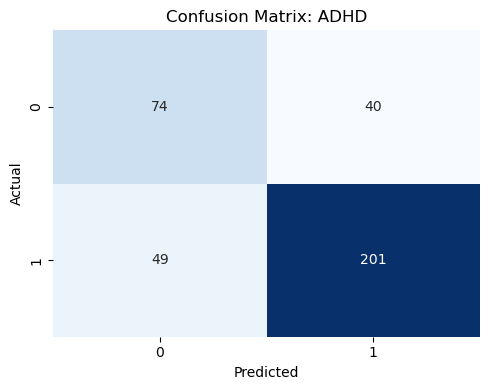


 Classification Report for Sex (F):
              precision    recall  f1-score   support

           0       0.68      0.84      0.75       239
           1       0.44      0.25      0.32       125

    accuracy                           0.63       364
   macro avg       0.56      0.54      0.53       364
weighted avg       0.60      0.63      0.60       364



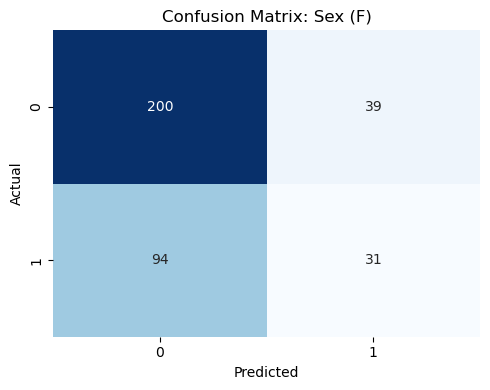

 Joint Accuracy: 0.5027
 F1 Score for ADHD: 0.8187
 Accuracy for ADHD: 0.7555
 F1 Score for Sex (F): 0.3179
 Accuracy for Sex (F): 0.6346


In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    make_scorer, f1_score, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings("ignore")

# === PIPELINE + GRID SEARCH ===
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

multi_clf = MultiOutputClassifier(rf, n_jobs=-1)

pipeline = Pipeline([
    ("clf", multi_clf)
])

param_grid = {
    "clf__estimator__n_estimators": [100, 200,250,300],  # Number of trees in the forest
    "clf__estimator__max_depth": [8, 9, 10,11,12],  # Max depth of the tree
    "clf__estimator__max_features": ["sqrt", "log2"],  # Features considered for best split
    "clf__estimator__criterion": ["gini", "entropy"],  # Function to measure quality of split
    "clf__estimator__min_samples_leaf": [ 4,6],  # Min samples at a leaf node
    "clf__estimator__min_samples_split": [4,5,6],  # Min samples required to split a node
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=custom_scorer,
    refit=True,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_resampled, y_resampled.values)

# === BEST MODEL RESULTS ===
print(" Best Params:", grid_search.best_params_)
print(" Best Custom Score (Train):", grid_search.best_score_)

best_model_RF = grid_search.best_estimator_
y_pred = best_model_RF.predict(X_test)
y_test_np = y_test.values

# === SCORE ON TEST SET ===
test_score = custom_competition_metric(y_test_np, y_pred)
print(" Custom Score (Test):", test_score)

# === EVALUATION METRICS ===
labels_dict = {0: "ADHD", 1: "Sex (F)"}

for i, label in enumerate(["ADHD", "Sex (F)"]):
    print(f"\n Classification Report for {label}:")
    print(classification_report(y_test_np[:, i], y_pred[:, i]))

    cm = confusion_matrix(y_test_np[:, i], y_pred[:, i])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix: {label}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0.5, 1.5], ["0", "1"])
    plt.yticks([0.5, 1.5], ["0", "1"])
    plt.tight_layout()
    plt.show()

# === JOINT ACCURACY ===
joint_accuracy = np.mean(np.all(y_test_np == y_pred, axis=1))
print(f" Joint Accuracy: {joint_accuracy:.4f}")

# === F1 SCORES AND ACCURACY ===
for i, label in enumerate(["ADHD", "Sex (F)"]):
    # F1 score
    f1 = f1_score(y_test_np[:, i], y_pred[:, i])
    print(f" F1 Score for {label}: {f1:.4f}")

    # Accuracy
    accuracy = np.mean(y_test_np[:, i] == y_pred[:, i])
    print(f" Accuracy for {label}: {accuracy:.4f}")


In [139]:
import joblib

# Assuming your model is in the variable model
joblib.dump(best_model_RF, 'RF_model_SMOTE_test.pkl')

['RF_model_SMOTE_test.pkl']

**Using the trained model on the original dataset before oversampling**

Evaluation on Original Unbalanced Data:
F1 Score for ADHD: 0.9394
Accuracy for ADHD: 0.9176
F1 Score for Sex (F): 0.8288
Accuracy for Sex (F): 0.8904
Joint Accuracy: 0.8417


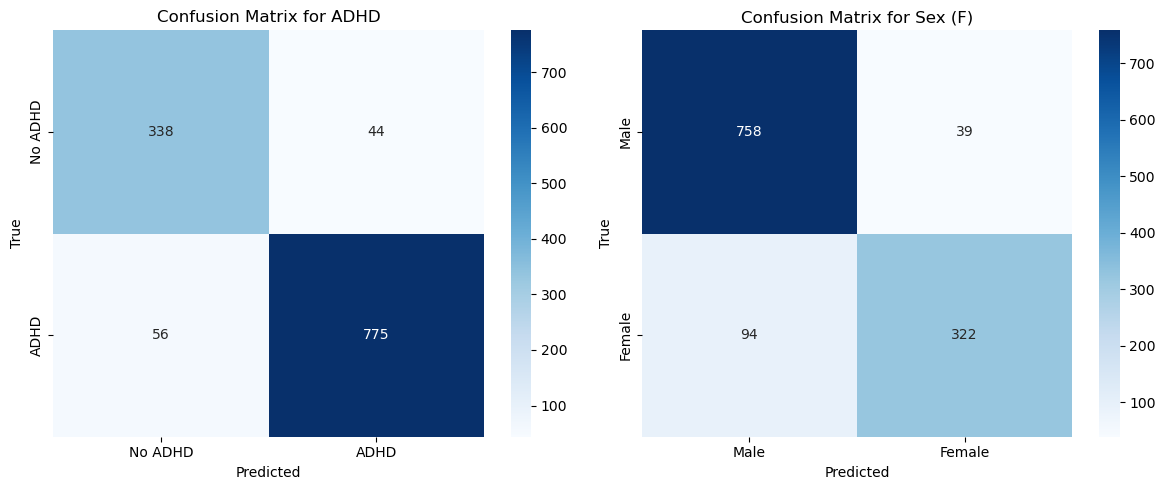

In [141]:
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score

# Assuming best_model is the trained model from your resampled data
# Combine features and targets and drop any rows with NaNs
original_combined = pd.concat([merged_df, s_df], axis=1).dropna()
X_orig = original_combined[merged_df.columns]
y_orig = original_combined[s_df.columns]

# Predict on the original unbalanced data
y_pred = best_model_RF.predict(X_orig)

# Convert predictions to DataFrame (if they are numpy arrays)
y_pred_df = pd.DataFrame(y_pred, columns=y_orig.columns)

# Align y_pred_df with y_orig's original index
y_pred_df.index = y_orig.index

# Evaluate ADHD metrics
adhd_f1 = f1_score(y_orig['ADHD_Outcome'], y_pred_df['ADHD_Outcome'])
adhd_acc = accuracy_score(y_orig['ADHD_Outcome'], y_pred_df['ADHD_Outcome'])

# Evaluate Sex (F) metrics
sex_f1 = f1_score(y_orig['Sex_F'], y_pred_df['Sex_F'])
sex_acc = accuracy_score(y_orig['Sex_F'], y_pred_df['Sex_F'])

# Joint Accuracy (both labels correct)
joint_acc = ((y_orig == y_pred_df).all(axis=1)).mean()

# Print the evaluation metrics
print(f"Evaluation on Original Unbalanced Data:")
print(f"F1 Score for ADHD: {adhd_f1:.4f}")
print(f"Accuracy for ADHD: {adhd_acc:.4f}")
print(f"F1 Score for Sex (F): {sex_f1:.4f}")
print(f"Accuracy for Sex (F): {sex_acc:.4f}")
print(f"Joint Accuracy: {joint_acc:.4f}")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix for ADHD (ADHD_Outcome)
adhd_cm = confusion_matrix(y_orig['ADHD_Outcome'], y_pred_df['ADHD_Outcome'])

# Generate confusion matrix for Sex (F)
sex_cm = confusion_matrix(y_orig['Sex_F'], y_pred_df['Sex_F'])

# Plot ADHD confusion matrix
plt.figure(figsize=(12, 5))

# ADHD confusion matrix plot
plt.subplot(1, 2, 1)
sns.heatmap(adhd_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No ADHD", "ADHD"], yticklabels=["No ADHD", "ADHD"])
plt.title("Confusion Matrix for ADHD")
plt.xlabel("Predicted")
plt.ylabel("True")

# Sex confusion matrix plot
plt.subplot(1, 2, 2)
sns.heatmap(sex_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Male", "Female"], yticklabels=["Male", "Female"])
plt.title("Confusion Matrix for Sex (F)")
plt.xlabel("Predicted")
plt.ylabel("True")

# Show the plot
plt.tight_layout()
plt.show()

**4. Logistic Regression**

Fitting 5 folds for each of 144 candidates, totalling 720 fits
 Best Params: {'clf__estimator__C': 800, 'clf__estimator__class_weight': 'balanced', 'clf__estimator__fit_intercept': False, 'clf__estimator__max_iter': 200, 'clf__estimator__penalty': 'l2', 'clf__estimator__solver': 'newton-cg'}
 Best Custom Score (Train): 0.6063099803649534
 Custom Score (Test): 0.6395869836569599

 Classification Report for ADHD:
              precision    recall  f1-score   support

           0       0.57      0.46      0.50       114
           1       0.77      0.84      0.80       250

    accuracy                           0.72       364
   macro avg       0.67      0.65      0.65       364
weighted avg       0.71      0.72      0.71       364



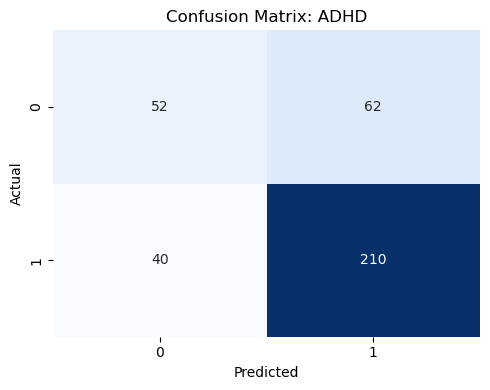


 Classification Report for Sex (F):
              precision    recall  f1-score   support

           0       0.72      0.58      0.64       239
           1       0.41      0.56      0.47       125

    accuracy                           0.57       364
   macro avg       0.56      0.57      0.56       364
weighted avg       0.61      0.57      0.58       364



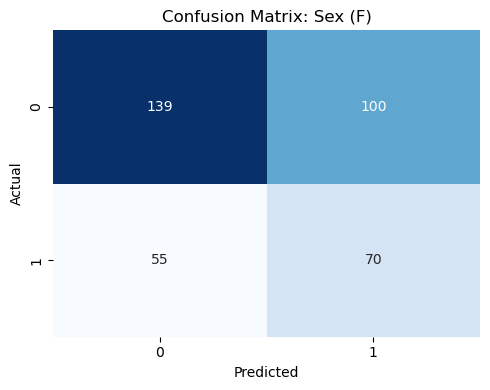

 Joint Accuracy: 0.4258
 F1 Score for ADHD: 0.8046
 Accuracy for ADHD: 0.7198
 F1 Score for Sex (F): 0.4746
 Accuracy for Sex (F): 0.5742


In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    make_scorer, f1_score, confusion_matrix, classification_report
)
import warnings

# Suppress specific warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')


# === PIPELINE + LOGISTIC REGRESSION ===
logreg = LogisticRegression(
    max_iter=3000
)

multi_logreg = MultiOutputClassifier(logreg)

pipeline = Pipeline([
    ("clf", multi_logreg)
])

# === GRID SEARCH ===
param_grid = {
    "clf__estimator__C": [ 800 ,1000,1200],  # Regularization strength
    "clf__estimator__penalty": ['l1', 'l2', 'elasticnet'],  # Regularization type
    "clf__estimator__solver": ['liblinear', 'saga', 'newton-cg', 'lbfgs'],  # Solvers
    "clf__estimator__max_iter": [200],  # Maximum iterations
    "clf__estimator__class_weight": ['balanced', None],  # Handle class imbalance
    "clf__estimator__fit_intercept": [True, False],  # Whether to include an intercept
}
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=custom_scorer,
    refit=True,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_resampled, y_resampled.values)

# === BEST MODEL ===
print(" Best Params:", grid_search.best_params_)
print(" Best Custom Score (Train):", grid_search.best_score_)

best_model_LR = grid_search.best_estimator_
y_pred = best_model_LR.predict(X_test)
y_test_np = y_test.values

# === EVALUATION ON TEST SET ===
test_score = custom_competition_metric(y_test_np, y_pred)
print(" Custom Score (Test):", test_score)

# === REPORTS & CONFUSION MATRICES ===
for i, label in enumerate(["ADHD", "Sex (F)"]):
    print(f"\n Classification Report for {label}:")
    print(classification_report(y_test_np[:, i], y_pred[:, i]))

    cm = confusion_matrix(y_test_np[:, i], y_pred[:, i])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix: {label}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0.5, 1.5], ["0", "1"])
    plt.yticks([0.5, 1.5], ["0", "1"])
    plt.tight_layout()
    plt.show()


# === JOINT ACCURACY ===
joint_accuracy = np.mean(np.all(y_test_np == y_pred, axis=1))
print(f" Joint Accuracy: {joint_accuracy:.4f}")

# === F1 SCORES AND ACCURACY ===
for i, label in enumerate(["ADHD", "Sex (F)"]):
    # F1 score
    f1 = f1_score(y_test_np[:, i], y_pred[:, i])
    print(f" F1 Score for {label}: {f1:.4f}")

    # Accuracy
    accuracy = np.mean(y_test_np[:, i] == y_pred[:, i])
    print(f" Accuracy for {label}: {accuracy:.4f}")

In [144]:
import joblib

# Assuming your model is in the variable model
joblib.dump(best_model_LR, 'LR_model_SMOTE_test.pkl')

['LR_model_SMOTE_test.pkl']

**Using the trained model on the original dataset before oversampling**

Evaluation on Original Unbalanced Data:
F1 Score for ADHD: 0.8396
Accuracy for ADHD: 0.7716
F1 Score for Sex (F): 0.5305
Accuracy for Sex (F): 0.6381
Joint Accuracy: 0.4930


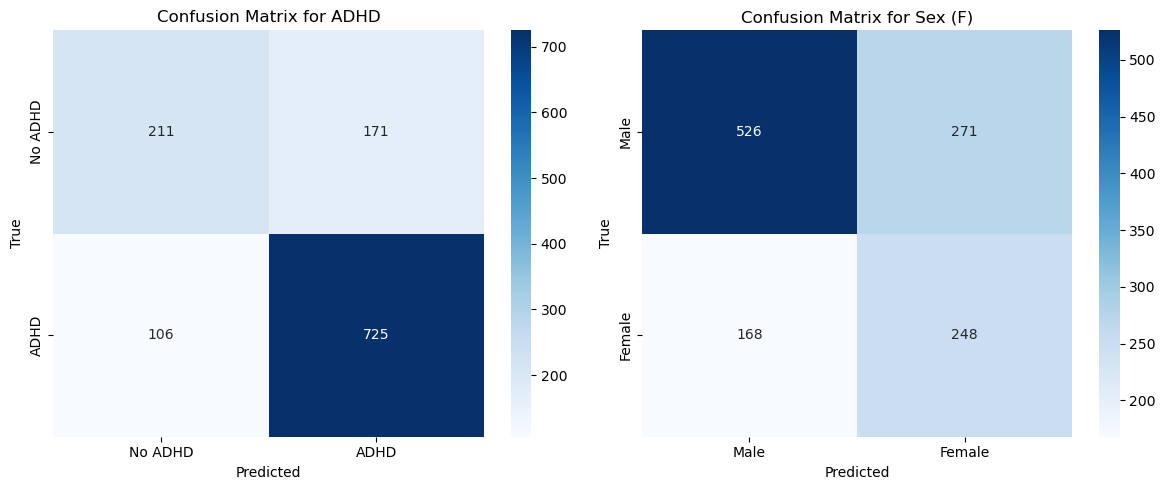

In [146]:
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score

# Assuming best_model is the trained model from your resampled data
# Combine features and targets and drop any rows with NaNs
original_combined = pd.concat([merged_df, s_df], axis=1).dropna()
X_orig = original_combined[merged_df.columns]
y_orig = original_combined[s_df.columns]

# Predict on the original unbalanced data
y_pred = best_model_LR.predict(X_orig)

# Convert predictions to DataFrame (if they are numpy arrays)
y_pred_df = pd.DataFrame(y_pred, columns=y_orig.columns)

# Align y_pred_df with y_orig's original index
y_pred_df.index = y_orig.index

# Evaluate ADHD metrics
adhd_f1 = f1_score(y_orig['ADHD_Outcome'], y_pred_df['ADHD_Outcome'])
adhd_acc = accuracy_score(y_orig['ADHD_Outcome'], y_pred_df['ADHD_Outcome'])

# Evaluate Sex (F) metrics
sex_f1 = f1_score(y_orig['Sex_F'], y_pred_df['Sex_F'])
sex_acc = accuracy_score(y_orig['Sex_F'], y_pred_df['Sex_F'])

# Joint Accuracy (both labels correct)
joint_acc = ((y_orig == y_pred_df).all(axis=1)).mean()

# Print the evaluation metrics
print(f"Evaluation on Original Unbalanced Data:")
print(f"F1 Score for ADHD: {adhd_f1:.4f}")
print(f"Accuracy for ADHD: {adhd_acc:.4f}")
print(f"F1 Score for Sex (F): {sex_f1:.4f}")
print(f"Accuracy for Sex (F): {sex_acc:.4f}")
print(f"Joint Accuracy: {joint_acc:.4f}")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix for ADHD (ADHD_Outcome)
adhd_cm = confusion_matrix(y_orig['ADHD_Outcome'], y_pred_df['ADHD_Outcome'])

# Generate confusion matrix for Sex (F)
sex_cm = confusion_matrix(y_orig['Sex_F'], y_pred_df['Sex_F'])

# Plot ADHD confusion matrix
plt.figure(figsize=(12, 5))

# ADHD confusion matrix plot
plt.subplot(1, 2, 1)
sns.heatmap(adhd_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No ADHD", "ADHD"], yticklabels=["No ADHD", "ADHD"])
plt.title("Confusion Matrix for ADHD")
plt.xlabel("Predicted")
plt.ylabel("True")

# Sex confusion matrix plot
plt.subplot(1, 2, 2)
sns.heatmap(sex_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Male", "Female"], yticklabels=["Male", "Female"])
plt.title("Confusion Matrix for Sex (F)")
plt.xlabel("Predicted")
plt.ylabel("True")

# Show the plot
plt.tight_layout()
plt.show()

**5.Bayesian Classification**

 Custom Score (Test): 0.498363413921564

 Classification Report for ADHD:
              precision    recall  f1-score   support

           0       0.39      0.79      0.52       114
           1       0.82      0.44      0.57       250

    accuracy                           0.55       364
   macro avg       0.60      0.61      0.55       364
weighted avg       0.68      0.55      0.55       364



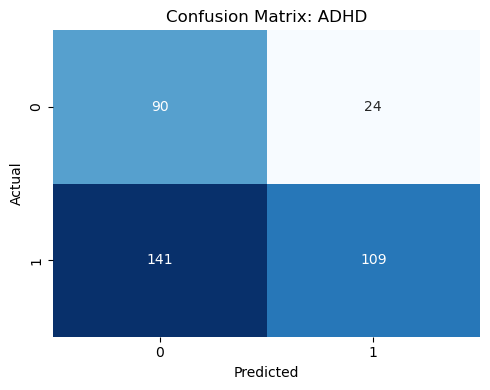


 Classification Report for Sex (F):
              precision    recall  f1-score   support

           0       0.69      0.62      0.65       239
           1       0.39      0.47      0.43       125

    accuracy                           0.57       364
   macro avg       0.54      0.54      0.54       364
weighted avg       0.59      0.57      0.57       364



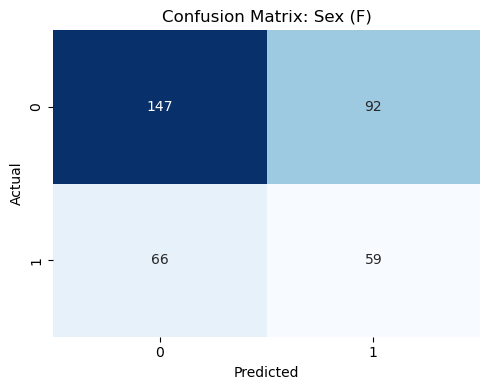

 Joint Accuracy: 0.3269
 F1 Score for ADHD: 0.5692
 Accuracy for ADHD: 0.5467
 F1 Score for Sex (F): 0.4275
 Accuracy for Sex (F): 0.5659


In [148]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.multioutput import MultiOutputClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, confusion_matrix, classification_report
)
import warnings

warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

# === PIPELINE WITH GAUSSIAN NAIVE BAYES ===
gnb = GaussianNB()
multi_gnb = MultiOutputClassifier(gnb)

pipeline = Pipeline([
    ("clf", multi_gnb)
])

# === NO HYPERPARAMS TO TUNE FOR GNB ===
# GaussianNB has very few parameters; we'll skip GridSearch for now

pipeline.fit(X_resampled, y_resampled.values)

# === PREDICTIONS & EVALUATION ===
y_pred = pipeline.predict(X_test)
y_test_np = y_test.values

# === EVALUATION ON TEST SET ===
test_score = custom_competition_metric(y_test_np, y_pred)
print(" Custom Score (Test):", test_score)

# === REPORTS & CONFUSION MATRICES ===
for i, label in enumerate(["ADHD", "Sex (F)"]):
    print(f"\n Classification Report for {label}:")
    print(classification_report(y_test_np[:, i], y_pred[:, i]))

    cm = confusion_matrix(y_test_np[:, i], y_pred[:, i])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix: {label}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# === JOINT ACCURACY AND F1 SCORES ===
joint_accuracy = np.mean(np.all(y_test_np == y_pred, axis=1))
print(f" Joint Accuracy: {joint_accuracy:.4f}")

for i, label in enumerate(["ADHD", "Sex (F)"]):
    f1 = f1_score(y_test_np[:, i], y_pred[:, i])
    acc = np.mean(y_test_np[:, i] == y_pred[:, i])
    print(f" F1 Score for {label}: {f1:.4f}")
    print(f" Accuracy for {label}: {acc:.4f}")



Evaluation on Original Unbalanced Data:
F1 Score for ADHD: 0.5512
Accuracy for ADHD: 0.5408
F1 Score for Sex (F): 0.4636
Accuracy for Sex (F): 0.5804
Joint Accuracy: 0.3298


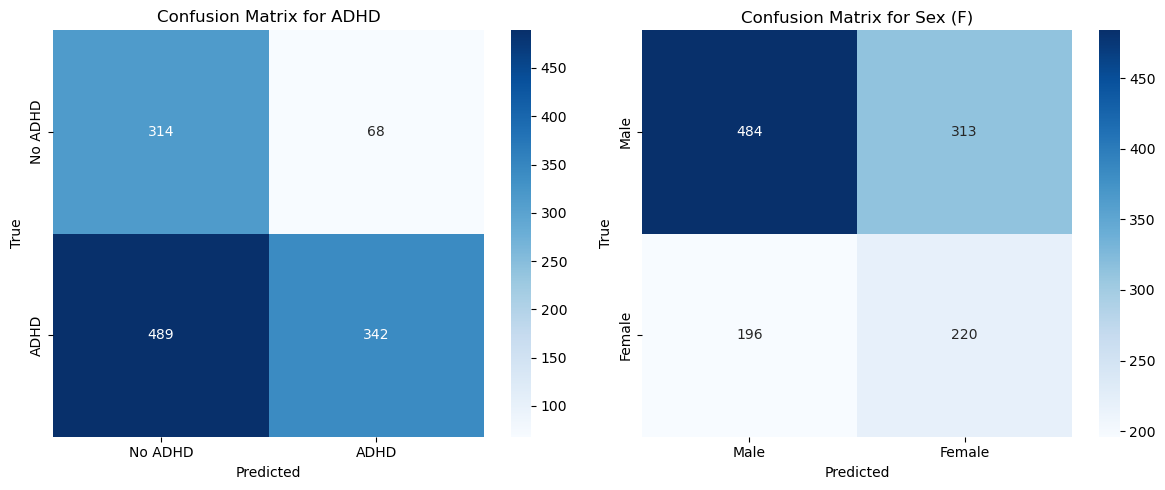

In [149]:
# === EVALUATION ON ORIGINAL UNBALANCED DATA ===
# Combine and drop NaNs
original_combined = pd.concat([merged_df, s_df], axis=1).dropna()
X_orig = original_combined[merged_df.columns]
y_orig = original_combined[s_df.columns]

# Predict using the trained pipeline
y_pred = pipeline.predict(X_orig)

# Convert predictions to DataFrame and align index
y_pred_df = pd.DataFrame(y_pred, columns=y_orig.columns, index=y_orig.index)

# ADHD Metrics
adhd_f1 = f1_score(y_orig['ADHD_Outcome'], y_pred_df['ADHD_Outcome'])
adhd_acc = accuracy_score(y_orig['ADHD_Outcome'], y_pred_df['ADHD_Outcome'])

# Sex (F) Metrics
sex_f1 = f1_score(y_orig['Sex_F'], y_pred_df['Sex_F'])
sex_acc = accuracy_score(y_orig['Sex_F'], y_pred_df['Sex_F'])

# Joint Accuracy
joint_acc = ((y_orig == y_pred_df).all(axis=1)).mean()

# Print metrics
print(f"\nEvaluation on Original Unbalanced Data:")
print(f"F1 Score for ADHD: {adhd_f1:.4f}")
print(f"Accuracy for ADHD: {adhd_acc:.4f}")
print(f"F1 Score for Sex (F): {sex_f1:.4f}")
print(f"Accuracy for Sex (F): {sex_acc:.4f}")
print(f"Joint Accuracy: {joint_acc:.4f}")

# === CONFUSION MATRICES ===
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix for ADHD (ADHD_Outcome)
adhd_cm = confusion_matrix(y_orig['ADHD_Outcome'], y_pred_df['ADHD_Outcome'])

# Generate confusion matrix for Sex (F)
sex_cm = confusion_matrix(y_orig['Sex_F'], y_pred_df['Sex_F'])

# Plot ADHD confusion matrix
plt.figure(figsize=(12, 5))

# ADHD confusion matrix plot
plt.subplot(1, 2, 1)
sns.heatmap(adhd_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No ADHD", "ADHD"], yticklabels=["No ADHD", "ADHD"])
plt.title("Confusion Matrix for ADHD")
plt.xlabel("Predicted")
plt.ylabel("True")

# Sex confusion matrix plot
plt.subplot(1, 2, 2)
sns.heatmap(sex_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Male", "Female"], yticklabels=["Male", "Female"])
plt.title("Confusion Matrix for Sex (F)")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.show()

**6.Neural Networks**

Fitting 5 folds for each of 48 candidates, totalling 240 fits
 Best Params: {'clf__estimator__activation': 'relu', 'clf__estimator__alpha': 0.001, 'clf__estimator__early_stopping': True, 'clf__estimator__hidden_layer_sizes': (100, 50), 'clf__estimator__learning_rate': 'adaptive', 'clf__estimator__solver': 'adam'}
 Best Custom Score (Train): 0.5896896825790641
 Custom Score (Test): 0.6389683022174024

 Classification Report for ADHD:
              precision    recall  f1-score   support

           0       0.64      0.54      0.59       114
           1       0.81      0.86      0.83       250

    accuracy                           0.76       364
   macro avg       0.72      0.70      0.71       364
weighted avg       0.75      0.76      0.76       364



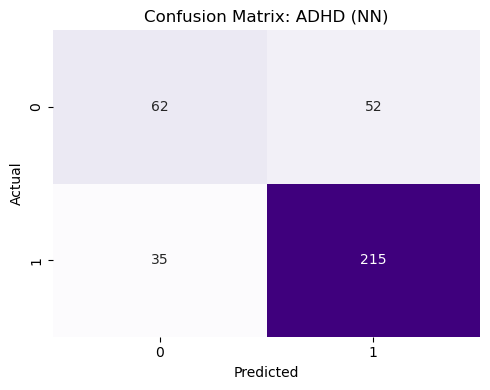


 Classification Report for Sex (F):
              precision    recall  f1-score   support

           0       0.71      0.71      0.71       239
           1       0.44      0.45      0.45       125

    accuracy                           0.62       364
   macro avg       0.58      0.58      0.58       364
weighted avg       0.62      0.62      0.62       364



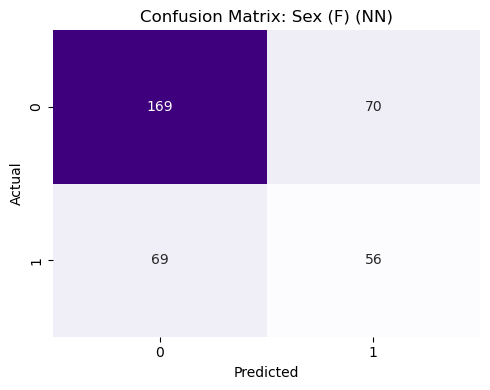

 Joint Accuracy: 0.4835
 F1 Score for ADHD: 0.8317
 Accuracy for ADHD: 0.7610
 F1 Score for Sex (F): 0.4462
 Accuracy for Sex (F): 0.6181


In [151]:
from sklearn.neural_network import MLPClassifier

# === PIPELINE + NEURAL NETWORK ===
mlp = MLPClassifier(max_iter=3000)

multi_mlp = MultiOutputClassifier(mlp)

pipeline_nn = Pipeline([
    ("clf", multi_mlp)
])

# === GRID SEARCH ===
param_grid_nn = {
    "clf__estimator__hidden_layer_sizes": [(50,), (100,), (100, 50)],
    "clf__estimator__activation": ['relu', 'tanh'],
    "clf__estimator__solver": ['adam', 'sgd'],
    "clf__estimator__alpha": [0.0001, 0.001],  # L2 penalty (regularization)
    "clf__estimator__learning_rate": ['constant', 'adaptive'],
    "clf__estimator__early_stopping": [True],
}

grid_search_nn = GridSearchCV(
    estimator=pipeline_nn,
    param_grid=param_grid_nn,
    scoring=custom_scorer,
    refit=True,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search_nn.fit(X_resampled, y_resampled.values)

# === BEST MODEL ===
print(" Best Params:", grid_search_nn.best_params_)
print(" Best Custom Score (Train):", grid_search_nn.best_score_)

best_model_NN = grid_search_nn.best_estimator_
y_pred_nn = best_model_NN.predict(X_test)

# === EVALUATION ===
test_score_nn = custom_competition_metric(y_test.values, y_pred_nn)
print(" Custom Score (Test):", test_score_nn)

# === REPORTS & CONFUSION MATRICES ===
for i, label in enumerate(["ADHD", "Sex (F)"]):
    print(f"\n Classification Report for {label}:")
    print(classification_report(y_test.values[:, i], y_pred_nn[:, i]))

    cm = confusion_matrix(y_test.values[:, i], y_pred_nn[:, i])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", cbar=False)
    plt.title(f"Confusion Matrix: {label} (NN)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0.5, 1.5], ["0", "1"])
    plt.yticks([0.5, 1.5], ["0", "1"])
    plt.tight_layout()
    plt.show()

# === JOINT ACCURACY ===
joint_accuracy_nn = np.mean(np.all(y_test.values == y_pred_nn, axis=1))
print(f" Joint Accuracy: {joint_accuracy_nn:.4f}")

# === F1 & ACCURACY ===
for i, label in enumerate(["ADHD", "Sex (F)"]):
    f1 = f1_score(y_test.values[:, i], y_pred_nn[:, i])
    accuracy = np.mean(y_test.values[:, i] == y_pred_nn[:, i])
    print(f" F1 Score for {label}: {f1:.4f}")
    print(f" Accuracy for {label}: {accuracy:.4f}")


Evaluation on Original Unbalanced Data:
F1 Score for ADHD: 0.8171
Accuracy for ADHD: 0.7420
F1 Score for Sex (F): 0.5864
Accuracy for Sex (F): 0.7337
Joint Accuracy: 0.5499


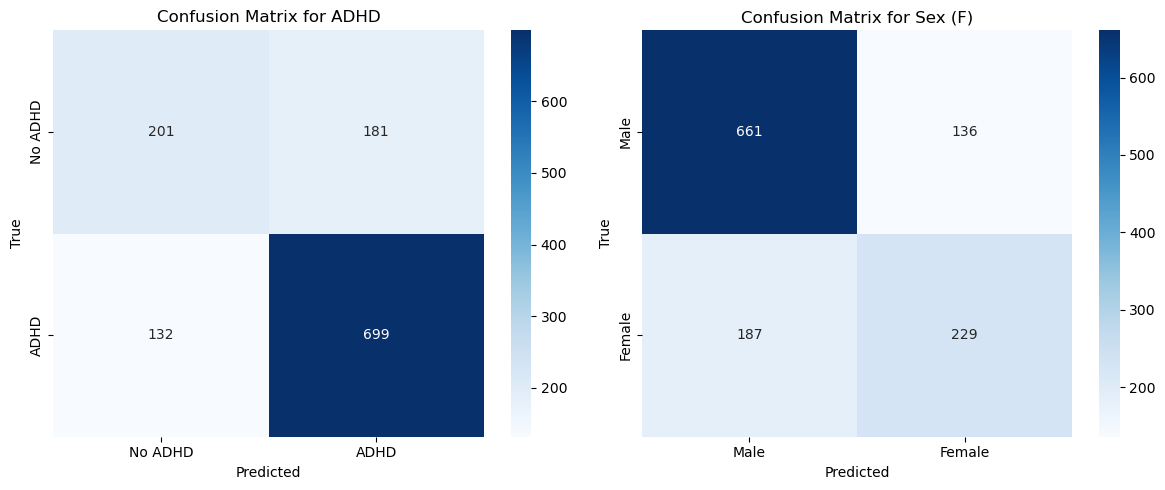

In [152]:
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score

# Assuming best_model is the trained model from your resampled data
# Combine features and targets and drop any rows with NaNs
original_combined = pd.concat([merged_df, s_df], axis=1).dropna()
X_orig = original_combined[merged_df.columns]
y_orig = original_combined[s_df.columns]

# Predict on the original unbalanced data
y_pred = best_model_NN.predict(X_orig)

# Convert predictions to DataFrame (if they are numpy arrays)
y_pred_df = pd.DataFrame(y_pred, columns=y_orig.columns)

# Align y_pred_df with y_orig's original index
y_pred_df.index = y_orig.index

# Evaluate ADHD metrics
adhd_f1 = f1_score(y_orig['ADHD_Outcome'], y_pred_df['ADHD_Outcome'])
adhd_acc = accuracy_score(y_orig['ADHD_Outcome'], y_pred_df['ADHD_Outcome'])

# Evaluate Sex (F) metrics
sex_f1 = f1_score(y_orig['Sex_F'], y_pred_df['Sex_F'])
sex_acc = accuracy_score(y_orig['Sex_F'], y_pred_df['Sex_F'])

# Joint Accuracy (both labels correct)
joint_acc = ((y_orig == y_pred_df).all(axis=1)).mean()

# Print the evaluation metrics
print(f"Evaluation on Original Unbalanced Data:")
print(f"F1 Score for ADHD: {adhd_f1:.4f}")
print(f"Accuracy for ADHD: {adhd_acc:.4f}")
print(f"F1 Score for Sex (F): {sex_f1:.4f}")
print(f"Accuracy for Sex (F): {sex_acc:.4f}")
print(f"Joint Accuracy: {joint_acc:.4f}")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix for ADHD (ADHD_Outcome)
adhd_cm = confusion_matrix(y_orig['ADHD_Outcome'], y_pred_df['ADHD_Outcome'])

# Generate confusion matrix for Sex (F)
sex_cm = confusion_matrix(y_orig['Sex_F'], y_pred_df['Sex_F'])

# Plot ADHD confusion matrix
plt.figure(figsize=(12, 5))

# ADHD confusion matrix plot
plt.subplot(1, 2, 1)
sns.heatmap(adhd_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No ADHD", "ADHD"], yticklabels=["No ADHD", "ADHD"])
plt.title("Confusion Matrix for ADHD")
plt.xlabel("Predicted")
plt.ylabel("True")

# Sex confusion matrix plot
plt.subplot(1, 2, 2)
sns.heatmap(sex_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Male", "Female"], yticklabels=["Male", "Female"])
plt.title("Confusion Matrix for Sex (F)")
plt.xlabel("Predicted")
plt.ylabel("True")

# Show the plot
plt.tight_layout()
plt.show()

In [153]:
import joblib

# Assuming your model is in the variable model
joblib.dump(best_model_LR, 'NN_model_SMOTE_test.pkl')

['NN_model_SMOTE_test.pkl']

**Test Dataset**

In [155]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
tc_df = pd.read_excel("TEST_CATEGORICAL.xlsx")
tq_df = pd.read_excel("TEST_QUANTITATIVE_METADATA.xlsx")
tfnc_df = pd.read_csv("TEST_FUNCTIONAL_CONNECTOME_MATRICES.csv")

In [156]:
tc_df.set_index('participant_id', inplace=True)
tc_df

,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ
participant_id,,,,,,,,,
Cfwaf5FX7jWK,2022,4,0.0,0.0,4,21.0,30.0,18.0,30.0
vhGrzmvA3Hjq,2023,4,0.0,0.0,4,21.0,45.0,NaN,30.0
ULliyEXjy4OV,2022,4,0.0,0.0,4,21.0,40.0,18.0,40.0
LZfeAb1xMtql,2022,4,0.0,0.0,3,21.0,45.0,21.0,45.0
EnFOUv0YK1RG,2022,4,2.0,0.0,4,18.0,0.0,21.0,45.0
...,...,...,...,...,...,...,...,...,...
UadZfjdEg7eG,2023,4,0.0,0.0,4,18.0,0.0,18.0,35.0
IUEHiLmQAqCi,2023,4,0.0,1.0,3,18.0,35.0,21.0,40.0
cRySmCadYFRO,2023,4,0.0,8.0,4,21.0,25.0,15.0,NaN


In [157]:
tq_df.set_index('participant_id', inplace=True)
tq_df

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
participant_id,,,,,,,,,,,,,,,,,,
Cfwaf5FX7jWK,60.03,14.0,5.0,16.0,41.0,19.0,11.0,26.0,2.0,12.0,3.0,9.0,2.0,7.0,3.0,0.0,8.0,8.992813
vhGrzmvA3Hjq,86.71,12.0,3.0,13.0,43.0,18.0,15.0,28.0,2.0,16.0,8.0,5.0,7.0,3.0,11.0,3.0,9.0,12.324093
ULliyEXjy4OV,26.68,13.0,3.0,14.0,36.0,16.0,14.0,25.0,1.0,7.0,1.0,6.0,1.0,5.0,1.0,0.0,9.0,7.770933
LZfeAb1xMtql,93.38,13.0,3.0,19.0,41.0,17.0,18.0,27.0,4.0,15.0,4.0,10.0,8.0,6.0,5.0,1.0,6.0,9.304814
EnFOUv0YK1RG,-93.38,14.0,3.0,13.0,42.0,19.0,16.0,28.0,2.0,18.0,6.0,12.0,5.0,10.0,6.0,0.0,10.0,8.261350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UadZfjdEg7eG,86.71,14.0,3.0,17.0,41.0,17.0,11.0,25.0,1.0,18.0,7.0,7.0,5.0,6.0,11.0,4.0,7.0,7.546999
IUEHiLmQAqCi,73.37,14.0,5.0,12.0,38.0,22.0,9.0,29.0,2.0,16.0,2.0,11.0,5.0,9.0,5.0,3.0,8.0,10.531143
cRySmCadYFRO,87.84,13.0,3.0,14.0,42.0,15.0,10.0,28.0,1.0,11.0,4.0,4.0,4.0,3.0,7.0,3.0,10.0,7.210586


In [158]:
tfnc_df.set_index('participant_id', inplace=True)
tfnc_df

,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,0throw_10thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
participant_id,,,,,,,,,,,,,,,,,,,,,
Cfwaf5FX7jWK,0.548480,0.713607,0.557319,0.524369,0.693364,0.770032,0.724406,0.390118,0.547912,0.470220,...,0.080423,-0.054581,-0.088163,-0.028574,0.444847,0.350149,-0.012601,0.665750,0.560565,0.555732
vhGrzmvA3Hjq,0.427740,0.363022,0.402862,0.363003,0.534558,0.345347,0.409471,0.303328,0.402515,0.275052,...,0.198009,-0.000724,0.083122,0.033043,0.687497,0.306229,0.717485,0.461809,0.559632,0.350027
ULliyEXjy4OV,0.139572,0.390106,-0.087041,0.196852,0.088148,0.023843,0.381782,0.068979,0.377488,0.301871,...,0.051319,0.023630,-0.056819,0.117396,0.576086,0.517831,0.527044,0.605038,0.609856,0.750987
LZfeAb1xMtql,0.133561,0.778326,0.416355,0.471840,0.568460,0.633660,0.501113,0.345461,0.467943,0.417308,...,0.046183,-0.238962,0.121868,-0.260970,0.646818,0.594902,0.608156,0.595459,0.683189,0.542296
EnFOUv0YK1RG,0.126699,0.575446,0.509422,0.363193,0.427544,0.449924,0.451796,0.223927,0.298248,0.304429,...,0.315734,0.002234,0.290791,0.344149,0.480214,0.539824,0.447322,0.293088,0.148529,0.539823
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UadZfjdEg7eG,0.029721,0.596742,0.361898,0.292066,0.553130,0.476284,0.543970,0.372932,0.595183,0.265432,...,0.021524,-0.162832,0.105546,0.028975,0.576180,0.378365,0.399277,0.556115,0.490833,0.568742
IUEHiLmQAqCi,0.025985,0.347840,0.304804,0.463090,0.305321,0.267397,0.468712,0.155677,0.298155,0.049262,...,0.044974,-0.078047,-0.118271,0.035741,0.640073,0.515096,0.206462,0.536001,0.318518,0.305596
cRySmCadYFRO,0.105385,0.443624,-0.019777,0.435582,0.376492,0.619322,0.430177,0.567600,0.399820,0.371101,...,0.145582,0.004455,0.134574,-0.152951,0.782938,0.737555,0.593972,0.734463,0.680979,0.678973


In [159]:
tc_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 304 entries, Cfwaf5FX7jWK to dQJXfyRazknD
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Basic_Demos_Enroll_Year           304 non-null    int64  
 1   Basic_Demos_Study_Site            304 non-null    int64  
 2   PreInt_Demos_Fam_Child_Ethnicity  301 non-null    float64
 3   PreInt_Demos_Fam_Child_Race       298 non-null    float64
 4   MRI_Track_Scan_Location           304 non-null    int64  
 5   Barratt_Barratt_P1_Edu            303 non-null    float64
 6   Barratt_Barratt_P1_Occ            303 non-null    float64
 7   Barratt_Barratt_P2_Edu            268 non-null    float64
 8   Barratt_Barratt_P2_Occ            262 non-null    float64
dtypes: float64(6), int64(3)
memory usage: 23.8+ KB


In [160]:
miss_perc_tc = tc_df.isnull().mean() * 100
miss_perc_tc

Basic_Demos_Enroll_Year              0.000000
Basic_Demos_Study_Site               0.000000
PreInt_Demos_Fam_Child_Ethnicity     0.986842
PreInt_Demos_Fam_Child_Race          1.973684
MRI_Track_Scan_Location              0.000000
Barratt_Barratt_P1_Edu               0.328947
Barratt_Barratt_P1_Occ               0.328947
Barratt_Barratt_P2_Edu              11.842105
Barratt_Barratt_P2_Occ              13.815789
dtype: float64

In [161]:
# Replace missing values in Barratt_Barratt_P2_Edu with -1
tc_df['Barratt_Barratt_P2_Edu'] = tc_df['Barratt_Barratt_P2_Edu'].fillna(-1)

# Replace missing values in Barratt_Barratt_P2_Occ with -1
tc_df['Barratt_Barratt_P2_Occ'] = tc_df['Barratt_Barratt_P2_Occ'].fillna(-1)

# Calculate the mode for each column and replace NaN values with the mode
tc_df['PreInt_Demos_Fam_Child_Ethnicity'] = tc_df['PreInt_Demos_Fam_Child_Ethnicity'].fillna(tc_df['PreInt_Demos_Fam_Child_Ethnicity'].mode()[0])
tc_df['PreInt_Demos_Fam_Child_Race'] = tc_df['PreInt_Demos_Fam_Child_Race'].fillna(tc_df['PreInt_Demos_Fam_Child_Race'].mode()[0])
tc_df['Barratt_Barratt_P1_Edu'] = tc_df['Barratt_Barratt_P1_Edu'].fillna(tc_df['Barratt_Barratt_P1_Edu'].mode()[0])
tc_df['Barratt_Barratt_P1_Occ'] = tc_df['Barratt_Barratt_P1_Occ'].fillna(tc_df['Barratt_Barratt_P1_Occ'].mode()[0])
miss_perc_tc = tc_df.isnull().mean() * 100
miss_perc_tc

Basic_Demos_Enroll_Year             0.0
Basic_Demos_Study_Site              0.0
PreInt_Demos_Fam_Child_Ethnicity    0.0
PreInt_Demos_Fam_Child_Race         0.0
MRI_Track_Scan_Location             0.0
Barratt_Barratt_P1_Edu              0.0
Barratt_Barratt_P1_Occ              0.0
Barratt_Barratt_P2_Edu              0.0
Barratt_Barratt_P2_Occ              0.0
dtype: float64

In [162]:
tq_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 304 entries, Cfwaf5FX7jWK to dQJXfyRazknD
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   EHQ_EHQ_Total               303 non-null    float64
 1   ColorVision_CV_Score        295 non-null    float64
 2   APQ_P_APQ_P_CP              289 non-null    float64
 3   APQ_P_APQ_P_ID              289 non-null    float64
 4   APQ_P_APQ_P_INV             289 non-null    float64
 5   APQ_P_APQ_P_OPD             289 non-null    float64
 6   APQ_P_APQ_P_PM              289 non-null    float64
 7   APQ_P_APQ_P_PP              289 non-null    float64
 8   SDQ_SDQ_Conduct_Problems    274 non-null    float64
 9   SDQ_SDQ_Difficulties_Total  274 non-null    float64
 10  SDQ_SDQ_Emotional_Problems  274 non-null    float64
 11  SDQ_SDQ_Externalizing       274 non-null    float64
 12  SDQ_SDQ_Generating_Impact   274 non-null    float64
 13  SDQ_SDQ_Hyperactivit

In [163]:
miss_perc_tq = tq_df.isnull().mean() * 100
miss_perc_tq

EHQ_EHQ_Total                 0.328947
ColorVision_CV_Score          2.960526
APQ_P_APQ_P_CP                4.934211
APQ_P_APQ_P_ID                4.934211
APQ_P_APQ_P_INV               4.934211
APQ_P_APQ_P_OPD               4.934211
APQ_P_APQ_P_PM                4.934211
APQ_P_APQ_P_PP                4.934211
SDQ_SDQ_Conduct_Problems      9.868421
SDQ_SDQ_Difficulties_Total    9.868421
SDQ_SDQ_Emotional_Problems    9.868421
SDQ_SDQ_Externalizing         9.868421
SDQ_SDQ_Generating_Impact     9.868421
SDQ_SDQ_Hyperactivity         9.868421
SDQ_SDQ_Internalizing         9.868421
SDQ_SDQ_Peer_Problems         9.868421
SDQ_SDQ_Prosocial             9.868421
MRI_Track_Age_at_Scan         0.000000
dtype: float64

In [164]:
tq_df.fillna(tq_df.median(), inplace=True)

In [165]:
miss_perc_tq = tq_df.isnull().mean() * 100
miss_perc_tq

EHQ_EHQ_Total                 0.0
ColorVision_CV_Score          0.0
APQ_P_APQ_P_CP                0.0
APQ_P_APQ_P_ID                0.0
APQ_P_APQ_P_INV               0.0
APQ_P_APQ_P_OPD               0.0
APQ_P_APQ_P_PM                0.0
APQ_P_APQ_P_PP                0.0
SDQ_SDQ_Conduct_Problems      0.0
SDQ_SDQ_Difficulties_Total    0.0
SDQ_SDQ_Emotional_Problems    0.0
SDQ_SDQ_Externalizing         0.0
SDQ_SDQ_Generating_Impact     0.0
SDQ_SDQ_Hyperactivity         0.0
SDQ_SDQ_Internalizing         0.0
SDQ_SDQ_Peer_Problems         0.0
SDQ_SDQ_Prosocial             0.0
MRI_Track_Age_at_Scan         0.0
dtype: float64

In [166]:
miss_perc_tf = tfnc_df.isnull().mean() * 100
miss_perc_tf

0throw_1thcolumn        0.0
0throw_2thcolumn        0.0
0throw_3thcolumn        0.0
0throw_4thcolumn        0.0
0throw_5thcolumn        0.0
                       ... 
196throw_198thcolumn    0.0
196throw_199thcolumn    0.0
197throw_198thcolumn    0.0
197throw_199thcolumn    0.0
198throw_199thcolumn    0.0
Length: 19900, dtype: float64

In [167]:
import pandas as pd

# Select only numerical columns
num_cols = tq_df.select_dtypes(include='number').columns

# Initialize dictionaries to store counts and percentages
outlier_counts = {}
outlier_percentage = {}

# Iterate through numerical columns
for col in num_cols:
    Q1 = tq_df[col].quantile(0.25)
    Q3 = tq_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Detect outliers
    outliers = (tq_df[col] < lower_bound) | (tq_df[col] > upper_bound)
    
    # Count outliers for the current column
    outlier_counts[col] = outliers.sum()
    
    # Calculate the percentage of outliers for the current column
    outlier_percentage[col] = (outlier_counts[col] / len(tq_df)) * 100

outlier_summary = pd.DataFrame({
    'Outlier Count': outlier_counts,
    'Outlier Percentage (%)': outlier_percentage
})

print("Outlier Summary (Count and Percentage):")
print(outlier_summary)

Outlier Summary (Count and Percentage):
                            Outlier Count  Outlier Percentage (%)
EHQ_EHQ_Total                          30                9.868421
ColorVision_CV_Score                   12                3.947368
APQ_P_APQ_P_CP                         53               17.434211
APQ_P_APQ_P_ID                          0                0.000000
APQ_P_APQ_P_INV                         5                1.644737
APQ_P_APQ_P_OPD                         1                0.328947
APQ_P_APQ_P_PM                          3                0.986842
APQ_P_APQ_P_PP                          2                0.657895
SDQ_SDQ_Conduct_Problems                2                0.657895
SDQ_SDQ_Difficulties_Total              0                0.000000
SDQ_SDQ_Emotional_Problems              1                0.328947
SDQ_SDQ_Externalizing                   1                0.328947
SDQ_SDQ_Generating_Impact               0                0.000000
SDQ_SDQ_Hyperactivity               

In [168]:
# Make a copy of the original DataFrame to apply capping/flooring
#q_df_capped = q_df.copy()

# Iterate through numerical columns again
for col in num_cols:
    Q1 = tq_df[col].quantile(0.25)
    Q3 = tq_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Apply capping and flooring
    tq_df[col] = tq_df[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers have been handled using capping and flooring.")


Outliers have been handled using capping and flooring.


In [169]:
import pandas as pd

# Select only numerical columns
num_cols = tfnc_df.select_dtypes(include='number').columns

# Initialize dictionaries to store counts and percentages
outlier_counts = {}
outlier_percentage = {}

# Iterate through numerical columns
for col in num_cols:
    Q1 = tfnc_df[col].quantile(0.25)
    Q3 = tfnc_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Detect outliers
    outliers = (tfnc_df[col] < lower_bound) | (tfnc_df[col] > upper_bound)
    
    # Count outliers for the current column
    outlier_counts[col] = outliers.sum()
    
    # Calculate the percentage of outliers for the current column
    outlier_percentage[col] = (outlier_counts[col] / len(tfnc_df)) * 100

outlier_summary = pd.DataFrame({
    'Outlier Count': outlier_counts,
    'Outlier Percentage (%)': outlier_percentage
})

print("Outlier Summary (Count and Percentage):")
print(outlier_summary)

Outlier Summary (Count and Percentage):
                      Outlier Count  Outlier Percentage (%)
0throw_1thcolumn                  3                0.986842
0throw_2thcolumn                  4                1.315789
0throw_3thcolumn                  2                0.657895
0throw_4thcolumn                  9                2.960526
0throw_5thcolumn                 10                3.289474
...                             ...                     ...
196throw_198thcolumn              1                0.328947
196throw_199thcolumn              4                1.315789
197throw_198thcolumn              6                1.973684
197throw_199thcolumn              7                2.302632
198throw_199thcolumn              7                2.302632

[19900 rows x 2 columns]


In [170]:
# Make a copy of the original DataFrame to apply capping/flooring
#fnc_df_capped = fnc_df.copy()

# Iterate through numerical columns again
for col in num_cols:
    Q1 = tfnc_df[col].quantile(0.25)
    Q3 = tfnc_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Apply capping and flooring
    tfnc_df[col] = tfnc_df[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers have been handled using capping and flooring.")


Outliers have been handled using capping and flooring.


In [171]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Apply Min-Max scaling
numeric_cols = tq_df.select_dtypes(include=['float64', 'int64']).columns
tq_df[numeric_cols] = scaler.fit_transform(tq_df[numeric_cols])

tq_df

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
participant_id,,,,,,,,,,,,,,,,,,
Cfwaf5FX7jWK,0.647696,1.0,0.0,0.588235,0.590909,0.615385,0.097561,0.724138,0.266667,0.413793,0.352941,0.514286,0.2,0.7,0.250000,0.000000,0.764706,0.145186
vhGrzmvA3Hjq,0.882565,0.2,0.0,0.411765,0.681818,0.564103,0.292683,0.862069,0.266667,0.551724,0.941176,0.285714,0.7,0.3,0.916667,0.400000,0.882353,0.388849
ULliyEXjy4OV,0.354109,0.6,0.0,0.470588,0.363636,0.461538,0.243902,0.655172,0.133333,0.241379,0.117647,0.342857,0.1,0.5,0.083333,0.000000,0.882353,0.055813
LZfeAb1xMtql,0.941283,0.6,0.0,0.764706,0.590909,0.512821,0.439024,0.793103,0.533333,0.517241,0.470588,0.571429,0.8,0.6,0.416667,0.133333,0.529412,0.168007
EnFOUv0YK1RG,0.000000,1.0,0.0,0.411765,0.636364,0.615385,0.341463,0.862069,0.266667,0.620690,0.705882,0.685714,0.5,1.0,0.500000,0.000000,1.000000,0.091684
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UadZfjdEg7eG,0.882565,1.0,0.0,0.647059,0.590909,0.512821,0.097561,0.655172,0.133333,0.620690,0.823529,0.400000,0.5,0.6,0.916667,0.533333,0.647059,0.039434
IUEHiLmQAqCi,0.765131,1.0,0.0,0.352941,0.454545,0.769231,0.000000,0.931034,0.266667,0.551724,0.235294,0.628571,0.5,0.9,0.416667,0.400000,0.764706,0.257706
cRySmCadYFRO,0.892513,0.6,0.0,0.470588,0.636364,0.410256,0.048780,0.862069,0.133333,0.379310,0.470588,0.228571,0.4,0.3,0.583333,0.400000,1.000000,0.014827


In [172]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Apply Min-Max scaling
numeric_cols = tfnc_df.select_dtypes(include=['float64', 'int64']).columns
tfnc_df[numeric_cols] = scaler.fit_transform(tfnc_df[numeric_cols])

tfnc_df

,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,0throw_10thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
participant_id,,,,,,,,,,,,,,,,,,,,,
Cfwaf5FX7jWK,0.812235,0.733984,0.729085,0.640430,0.791782,0.820169,0.783647,0.588572,0.656915,0.679791,...,0.466339,0.408403,0.425792,0.425820,0.357745,0.549585,0.132043,0.756156,0.675983,0.581282
vhGrzmvA3Hjq,0.713549,0.245617,0.597740,0.492255,0.642262,0.313897,0.437123,0.508202,0.518086,0.526298,...,0.589876,0.457639,0.576878,0.484008,0.720742,0.503606,0.946826,0.500048,0.674819,0.309215
ULliyEXjy4OV,0.478017,0.283346,0.181145,0.339686,0.221956,0.000000,0.406656,0.291186,0.494190,0.547391,...,0.435763,0.479904,0.453440,0.563667,0.554075,0.725131,0.734292,0.679915,0.737516,0.839526
LZfeAb1xMtql,0.473103,0.824138,0.609214,0.592195,0.674181,0.657599,0.537956,0.547218,0.580559,0.638177,...,0.430366,0.239840,0.611055,0.206356,0.659888,0.805816,0.824814,0.667885,0.829060,0.563512
EnFOUv0YK1RG,0.467495,0.541526,0.688355,0.492429,0.541506,0.438565,0.483693,0.434673,0.418530,0.549403,...,0.713557,0.460343,0.760057,0.777802,0.410653,0.748155,0.645321,0.288170,0.161622,0.560241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UadZfjdEg7eG,0.388230,0.571191,0.562906,0.427117,0.659748,0.469990,0.585113,0.572657,0.702049,0.518733,...,0.404460,0.309439,0.596657,0.480166,0.554216,0.579124,0.591702,0.618477,0.588934,0.598489
IUEHiLmQAqCi,0.385176,0.224469,0.514356,0.584160,0.426429,0.220973,0.502306,0.371471,0.418441,0.348723,...,0.429096,0.386950,0.399235,0.486556,0.649798,0.722268,0.376519,0.593218,0.373826,0.250451
cRySmCadYFRO,0.450073,0.357897,0.238343,0.558901,0.493439,0.640506,0.459905,0.752927,0.515513,0.601838,...,0.534795,0.462374,0.622262,0.308365,0.863520,0.955160,0.808984,0.842446,0.826301,0.744281


In [173]:
selected_features = ['0throw_153thcolumn', '105throw_108thcolumn', '119throw_157thcolumn', '119throw_175thcolumn', '124throw_153thcolumn', 
'128throw_193thcolumn', '12throw_65thcolumn', '137throw_165thcolumn', '143throw_150thcolumn', '147throw_187thcolumn', '149throw_161thcolumn', 
'14throw_127thcolumn', '14throw_28thcolumn', '156throw_168thcolumn', '157throw_172thcolumn', '162throw_186thcolumn', '164throw_181thcolumn', 
'16throw_68thcolumn', '174throw_175thcolumn', '17throw_130thcolumn', '17throw_192thcolumn', '18throw_184thcolumn', '1throw_55thcolumn', 
'20throw_34thcolumn', '23throw_170thcolumn', '27throw_63thcolumn', '28throw_54thcolumn', '30throw_34thcolumn', '31throw_54thcolumn', 
'33throw_55thcolumn', '36throw_55thcolumn', '3throw_171thcolumn', '3throw_172thcolumn', '3throw_173thcolumn', '3throw_67thcolumn', 
'44throw_142thcolumn', '45throw_52thcolumn', '49throw_72thcolumn', '50throw_53thcolumn', '50throw_83thcolumn', '51throw_53thcolumn', 
'52throw_64thcolumn', '53throw_144thcolumn', '54throw_153thcolumn', '54throw_173thcolumn', '55throw_133thcolumn', '60throw_61thcolumn', 
'62throw_103thcolumn', '64throw_161thcolumn', '66throw_77thcolumn', '69throw_131thcolumn', '72throw_92thcolumn', '77throw_129thcolumn', 
'80throw_111thcolumn', '88throw_134thcolumn', '8throw_125thcolumn', '92throw_138thcolumn', '97throw_143thcolumn', '99throw_100thcolumn', 
                     '9throw_182thcolumn']


# Filter fnc_df to keep only those columns
tfnc_df_filtered = tfnc_df[selected_features]

In [174]:
#Convert numeric columns to string (if they are represented as numbers but should be categorical)
tc_df = tc_df.applymap(str)
columns_to_drop = [
    'Barratt_Barratt_P1_Occ',
    'Basic_Demos_Enroll_Year',
    'Basic_Demos_Study_Site',
    'MRI_Track_Scan_Location',
    'PreInt_Demos_Fam_Child_Race'
]
tc_df = tc_df.drop(columns=columns_to_drop)
#One-hot encode all categorical columns
tc_df_encoded = pd.get_dummies(tc_df)
#Display the new DataFrame with one-hot encoded columns
tc_df_encoded

,PreInt_Demos_Fam_Child_Ethnicity_0.0,PreInt_Demos_Fam_Child_Ethnicity_1.0,PreInt_Demos_Fam_Child_Ethnicity_2.0,PreInt_Demos_Fam_Child_Ethnicity_3.0,Barratt_Barratt_P1_Edu_12.0,Barratt_Barratt_P1_Edu_15.0,Barratt_Barratt_P1_Edu_18.0,Barratt_Barratt_P1_Edu_21.0,Barratt_Barratt_P1_Edu_3.0,Barratt_Barratt_P1_Edu_6.0,...,Barratt_Barratt_P2_Occ_0.0,Barratt_Barratt_P2_Occ_10.0,Barratt_Barratt_P2_Occ_15.0,Barratt_Barratt_P2_Occ_20.0,Barratt_Barratt_P2_Occ_25.0,Barratt_Barratt_P2_Occ_30.0,Barratt_Barratt_P2_Occ_35.0,Barratt_Barratt_P2_Occ_40.0,Barratt_Barratt_P2_Occ_45.0,Barratt_Barratt_P2_Occ_5.0
participant_id,,,,,,,,,,,,,,,,,,,,,
Cfwaf5FX7jWK,True,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
vhGrzmvA3Hjq,True,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
ULliyEXjy4OV,True,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
LZfeAb1xMtql,True,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
EnFOUv0YK1RG,False,False,True,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UadZfjdEg7eG,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
IUEHiLmQAqCi,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
cRySmCadYFRO,True,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [175]:
# Merge all DataFrames on 'participant_id'
t_merged_df = tq_df.merge(tc_df_encoded, on='participant_id') \
                .merge(tfnc_df_filtered, on='participant_id')
t_merged_df

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,...,69throw_131thcolumn,72throw_92thcolumn,77throw_129thcolumn,80throw_111thcolumn,88throw_134thcolumn,8throw_125thcolumn,92throw_138thcolumn,97throw_143thcolumn,99throw_100thcolumn,9throw_182thcolumn
participant_id,,,,,,,,,,,,,,,,,,,,,
Cfwaf5FX7jWK,0.647696,1.0,0.0,0.588235,0.590909,0.615385,0.097561,0.724138,0.266667,0.413793,...,0.469999,0.576663,0.481665,0.679248,0.401459,0.718351,0.649883,0.190981,0.340337,0.029268
vhGrzmvA3Hjq,0.882565,0.2,0.0,0.411765,0.681818,0.564103,0.292683,0.862069,0.266667,0.551724,...,0.170144,0.041509,0.436029,0.665262,0.171182,0.130974,0.177490,0.751656,0.114362,0.495448
ULliyEXjy4OV,0.354109,0.6,0.0,0.470588,0.363636,0.461538,0.243902,0.655172,0.133333,0.241379,...,0.517635,0.504358,0.336673,0.598440,0.277044,0.393646,0.386185,0.303554,0.653427,0.535274
LZfeAb1xMtql,0.941283,0.6,0.0,0.764706,0.590909,0.512821,0.439024,0.793103,0.533333,0.517241,...,0.602176,0.402873,0.419900,0.554711,0.229809,0.277717,0.369180,0.315679,0.467095,0.677447
EnFOUv0YK1RG,0.000000,1.0,0.0,0.411765,0.636364,0.615385,0.341463,0.862069,0.266667,0.620690,...,0.283580,0.687341,0.444061,0.561678,0.384134,0.274578,0.834508,0.362416,0.421084,0.879014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UadZfjdEg7eG,0.882565,1.0,0.0,0.647059,0.590909,0.512821,0.097561,0.655172,0.133333,0.620690,...,0.558884,0.246206,0.371153,0.394694,0.615534,0.656603,0.437160,0.463212,0.503938,0.149565
IUEHiLmQAqCi,0.765131,1.0,0.0,0.352941,0.454545,0.769231,0.000000,0.931034,0.266667,0.551724,...,0.787140,0.548967,0.302134,0.475993,0.074266,0.324763,0.474749,0.468725,0.287340,0.638077
cRySmCadYFRO,0.892513,0.6,0.0,0.470588,0.636364,0.410256,0.048780,0.862069,0.133333,0.379310,...,0.578711,0.687886,0.535936,0.592992,0.602334,0.367963,0.491931,0.437790,0.183693,0.435700


In [176]:
# Ensure test_encoded has the same columns as train_encoded
missing_cols_m = set(merged_df.columns) - set(t_merged_df.columns)

# Ensure test_encoded columns are in the same order as train_encoded
t_merged_df= t_merged_df.reindex(columns=merged_df.columns, fill_value=0)
missing_cols_m

set()

In [177]:
# Ensure test_encoded has the same columns as train_encoded
missing_cols_m = set(t_merged_df.columns) - set(merged_df.columns)

# Ensure test_encoded columns are in the same order as train_encoded
#tc_df_encoded = tc_df_encoded.reindex(columns=c_df_encoded.columns, fill_value=0)
missing_cols_m

set()

In [178]:
import joblib
# Load the pipeline
loaded_model = joblib.load('KNN_model_SMOTE_test.pkl')
# Predict on test_df
y_pred = loaded_model.predict(t_merged_df)

# If you want probabilities:
# Combine ID column with predictions
y_pred_df = pd.DataFrame(y_pred, columns=['ADHD_Outcome', 'Sex_F'])
# Reset index from test_df to get IDs as a column
ids = t_merged_df.index.to_series().reset_index(drop=True)

# Add IDs to predictions DataFrame
y_pred_df['participant_id'] = ids
# Optional: move 'ID' to the front
y_pred_df = y_pred_df[['participant_id', 'ADHD_Outcome', 'Sex_F']]
# Save the predictions to a CSV file
y_pred_df.to_csv('predictions_KNN_SMOTE_test.csv', index=False)

# Show the result
y_pred_df

,participant_id,ADHD_Outcome,Sex_F
0,Cfwaf5FX7jWK,1,0
1,vhGrzmvA3Hjq,1,0
2,ULliyEXjy4OV,0,1
3,LZfeAb1xMtql,0,1
4,EnFOUv0YK1RG,0,0
...,...,...,...
299,UadZfjdEg7eG,0,0
300,IUEHiLmQAqCi,0,1
301,cRySmCadYFRO,1,1
302,E3MvDUtJadc5,0,1


In [179]:
import joblib
# Load the pipeline
loaded_model = joblib.load('LR_model_SMOTE_test.pkl')
# Predict on test_df
y_pred = loaded_model.predict(t_merged_df)

# If you want probabilities:
# Combine ID column with predictions
y_pred_df = pd.DataFrame(y_pred, columns=['ADHD_Outcome', 'Sex_F'])
# Reset index from test_df to get IDs as a column
ids = t_merged_df.index.to_series().reset_index(drop=True)

# Add IDs to predictions DataFrame
y_pred_df['participant_id'] = ids
# Optional: move 'ID' to the front
y_pred_df = y_pred_df[['participant_id', 'ADHD_Outcome', 'Sex_F']]
# Save the predictions to a CSV file
y_pred_df.to_csv('predictions_LR_SMOTE_test.csv', index=False)

# Show the result
y_pred_df
y_pred_df.value_counts().sum()

304

In [180]:
import joblib
# Load the pipeline
loaded_model = joblib.load('RF_model_SMOTE_test.pkl')
# Predict on test_df
y_pred = loaded_model.predict(t_merged_df)

# If you want probabilities:
# Combine ID column with predictions
y_pred_df = pd.DataFrame(y_pred, columns=['ADHD_Outcome', 'Sex_F'])
# Reset index from test_df to get IDs as a column
ids = t_merged_df.index.to_series().reset_index(drop=True)

# Add IDs to predictions DataFrame
y_pred_df['participant_id'] = ids
# Optional: move 'ID' to the front
y_pred_df = y_pred_df[['participant_id', 'ADHD_Outcome', 'Sex_F']]
# Save the predictions to a CSV file
y_pred_df.to_csv('predictions_RF_SMOTE_test.csv', index=False)

# Show the result
y_pred_df
y_pred_df.value_counts().sum()

304

In [181]:
import joblib
# Load the pipeline
loaded_model = joblib.load('DT_model_SMOTE_test.pkl')
# Predict on test_df
y_pred = loaded_model.predict(t_merged_df)

# If you want probabilities:
# Combine ID column with predictions
y_pred_df = pd.DataFrame(y_pred, columns=['ADHD_Outcome', 'Sex_F'])
# Reset index from test_df to get IDs as a column
ids = t_merged_df.index.to_series().reset_index(drop=True)

# Add IDs to predictions DataFrame
y_pred_df['participant_id'] = ids
# Optional: move 'ID' to the front
y_pred_df = y_pred_df[['participant_id', 'ADHD_Outcome', 'Sex_F']]
# Save the predictions to a CSV file
y_pred_df.to_csv('predictions_DT_SMOTE_test.csv', index=False)

# Show the result
y_pred_df

,participant_id,ADHD_Outcome,Sex_F
0,Cfwaf5FX7jWK,1,0
1,vhGrzmvA3Hjq,1,0
2,ULliyEXjy4OV,0,0
3,LZfeAb1xMtql,1,0
4,EnFOUv0YK1RG,1,0
...,...,...,...
299,UadZfjdEg7eG,1,1
300,IUEHiLmQAqCi,1,0
301,cRySmCadYFRO,0,0
302,E3MvDUtJadc5,0,0


In [182]:
import joblib
# Load the pipeline
loaded_model = joblib.load('NN_model_SMOTE_test.pkl')
# Predict on test_df
y_pred = loaded_model.predict(t_merged_df)

# If you want probabilities:
# Combine ID column with predictions
y_pred_df = pd.DataFrame(y_pred, columns=['ADHD_Outcome', 'Sex_F'])
# Reset index from test_df to get IDs as a column
ids = t_merged_df.index.to_series().reset_index(drop=True)

# Add IDs to predictions DataFrame
y_pred_df['participant_id'] = ids
# Optional: move 'ID' to the front
y_pred_df = y_pred_df[['participant_id', 'ADHD_Outcome', 'Sex_F']]
# Save the predictions to a CSV file
y_pred_df.to_csv('predictions_NN_SMOTE_test.csv', index=False)

# Show the result
y_pred_df

,participant_id,ADHD_Outcome,Sex_F
0,Cfwaf5FX7jWK,1,0
1,vhGrzmvA3Hjq,1,1
2,ULliyEXjy4OV,1,1
3,LZfeAb1xMtql,1,0
4,EnFOUv0YK1RG,1,1
...,...,...,...
299,UadZfjdEg7eG,1,1
300,IUEHiLmQAqCi,1,1
301,cRySmCadYFRO,1,0
302,E3MvDUtJadc5,1,0
